# Task 1 — Exploratory Data Analysis
**Dataset:** MachineLearningRating_v3.txt (~1 million rows, 52 columns)  
**Goal:** Assess data quality and uncover initial patterns in risk and profitability.

**Sections**
1. Setup & Load
2. Data Summarization — descriptive stats & dtype review
3. Data Quality Assessment — missing values & handling strategy
4. Univariate Analysis — histograms & bar charts
5. Bivariate & Multivariate Analysis — scatter, correlations
6. Geographic Trends — premium, cover type, make by province
7. Outlier Detection — box plots & IQR table

In [1]:
import sys
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings("ignore")

import math
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import seaborn as sns

from src.data_loader import load_data, summarize_data, compute_loss_ratio, flag_high_missing
from src.eda_utils import (
    descriptive_stats, dtype_review,
    missing_summary_table,
    plot_numeric_distributions, plot_categorical_counts,
    loss_ratio_by_group, plot_loss_ratio_by_group,
    correlation_heatmap,
    plot_monthly_trend,
    outlier_summary, plot_boxplots,
    scatter_premium_vs_claims,
    premium_by_province, cover_type_by_province, top_makes_by_province,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid", palette="muted")

## 1. Load Data

In [2]:
df = load_data("../data/MachineLearningRating_v3.txt")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head(3)

Shape: 1,000,098 rows x 52 columns


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,MaritalStatus,Gender,Country,Province,PostalCode,MainCrestaZone,SubCrestaZone,ItemType,mmcode,VehicleType,RegistrationYear,make,Model,Cylinders,cubiccapacity,kilowatts,bodytype,NumberOfDoors,VehicleIntroDate,CustomValueEstimate,AlarmImmobiliser,TrackingDevice,CapitalOutstanding,NewVehicle,WrittenOff,Rebuilt,Converted,CrossBorder,NumberOfVehiclesInFleet,SumInsured,TermFrequency,CalculatedPremiumPerTerm,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6,2597,130,S/D,4,6/2002,119300.0000,Yes,No,119300.0000,NaN,NaN,NaN,NaN,NaN,<NA>,0.0100,Monthly,25.0000,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.9298,0.0000
1,145249,12827,2015-05-01,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6,2597,130,S/D,4,6/2002,119300.0000,Yes,No,119300.0000,NaN,NaN,NaN,NaN,NaN,<NA>,0.0100,Monthly,25.0000,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.9298,0.0000
2,145249,12827,2015-07-01,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6,2597,130,S/D,4,6/2002,119300.0000,Yes,No,119300.0000,NaN,NaN,NaN,NaN,NaN,<NA>,0.0100,Monthly,25.0000,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.0000,0.0000


---
## 2. Data Summarization

### 2.1 Descriptive Statistics — All Numerical Features

In [3]:
descriptive_stats(df)

,UnderwrittenCoverID,PolicyID,RegistrationYear,Cylinders,cubiccapacity,kilowatts,NumberOfDoors,CustomValueEstimate,CapitalOutstanding,NumberOfVehiclesInFleet,SumInsured,CalculatedPremiumPerTerm,TotalPremium,TotalClaims
count,1000098.0000,1000098.0000,1000098.0000,999546.0000,999546.0000,999546.0000,999546.0000,220456.0000,1000096.0000,0.0000,1000098.0000,1000098.0000,1000098.0000,1000098.0000
mean,104817.5461,7956.6825,2010.2254,4.0466,2466.7433,97.2079,4.0192,225531.1299,52678.6071,<NA>,604172.7326,117.8757,61.9055,64.8612
std,63293.7085,5290.0385,3.2614,0.2940,442.8006,19.3933,0.4683,564515.7498,111474.8707,<NA>,1508331.8380,399.7017,230.2845,2384.0747
min,1.0000,14.0000,1987.0000,0.0000,0.0000,0.0000,0.0000,20000.0000,-2.0000,<NA>,0.0100,0.0000,-782.5768,-12002.4123
25%,55143.0000,4500.0000,2008.0000,4.0000,2237.0000,75.0000,4.0000,135000.0000,0.0000,<NA>,5000.0000,3.2248,0.0000,0.0000
50%,94083.0000,7071.0000,2011.0000,4.0000,2694.0000,111.0000,4.0000,220000.0000,0.0000,<NA>,7500.0000,8.4369,2.1783,0.0000
75%,139190.0000,11077.0000,2013.0000,4.0000,2694.0000,111.0000,4.0000,280000.0000,0.0000,<NA>,250000.0000,90.0000,21.9298,0.0000
max,301175.0000,23246.0000,2015.0000,10.0000,12880.0000,309.0000,6.0000,26550000.0000,700000.0000,<NA>,12636200.0000,74422.1679,65282.6034,393092.1053
skewness,0.6117,0.7374,-0.7945,5.7046,3.5760,0.2447,-2.5313,40.8705,2.0125,<NA>,2.5486,122.9746,138.5965,69.9331
kurtosis,0.0288,0.2820,0.6081,71.2853,102.2898,3.0100,18.8338,1762.3216,3.2508,<NA>,4.6452,22210.7017,37176.1855,6791.9262


### 2.2 Financial Columns Close-up

Focus on , , and related columns that drive risk modelling.

In [4]:
financial_cols = ["TotalPremium", "TotalClaims", "SumInsured",
                  "CalculatedPremiumPerTerm", "CapitalOutstanding"]
df[financial_cols].describe().T.assign(
    zeros=(df[financial_cols] == 0).sum(),
    zeros_pct=(df[financial_cols] == 0).mean().mul(100).round(2),
    skewness=df[financial_cols].skew(),
)

,count,mean,std,min,25%,50%,75%,max,zeros,zeros_pct,skewness
TotalPremium,1000098.0000,61.9055,230.2845,-782.5768,0.0000,2.1783,21.9298,65282.6034,381634,38.1600,138.5965
TotalClaims,1000098.0000,64.8612,2384.0747,-12002.4123,0.0000,0.0000,0.0000,393092.1053,997305,99.7200,69.9331
SumInsured,1000098.0000,604172.7326,1508331.8380,0.0100,5000.0000,7500.0000,250000.0000,12636200.0000,0,0.0000,2.5486
CalculatedPremiumPerTerm,1000098.0000,117.8757,399.7017,0.0000,3.2248,8.4369,90.0000,74422.1679,7,0.0000,122.9746
CapitalOutstanding,1000096.0000,52678.6071,111474.8707,-2.0000,0.0000,0.0000,0.0000,700000.0000,792780,79.2700,2.0125


**Observations**
-  is 99.7% zero — zero-inflated distribution typical of insurance portfolios.
-  is 38.2% zero — warrants investigation (possible data entry or zero-premium add-ons).
- Both columns show extreme positive skewness; a log transform will be required for modelling.

### 2.3 Dtype Review

In [5]:
review = dtype_review(df)
review

,stored_dtype,semantic_type,flag
column,,,
UnderwrittenCoverID,Int64,numerical,
PolicyID,Int64,numerical,
TransactionMonth,datetime64[ns],datetime,
IsVATRegistered,bool,boolean,
Citizenship,object,categorical,
LegalType,object,categorical,
Title,object,categorical,
Language,object,categorical,
Bank,object,categorical,


In [6]:
flagged = review[review["flag"] != ""]
print(f"{len(flagged)} columns flagged:")
flagged

4 columns flagged:


,stored_dtype,semantic_type,flag
column,,,
PostalCode,object,categorical,>90% values numeric but stored as object
mmcode,object,categorical,>90% values numeric but stored as object
VehicleIntroDate,object,categorical,may be datetime — consider pd.to_datetime
NumberOfVehiclesInFleet,Int64,numerical,looks boolean — consider casting


**Dtype corrections needed**

| Column | Issue | Recommended action |
|---|---|---|
|  | Stored as object, >90% numeric | Cast to  or keep as string category |
|  | Stored as object, >90% numeric | Cast to  |
|  | Date string () | Parse with  |
|  | All null — looks boolean | Drop or investigate source |

---
## 3. Data Quality Assessment

### 3.1 Missing Values

In [7]:
summary = summarize_data(df)
print(f"Total rows            : {summary['shape'][0]:,}")
print(f"Total columns         : {summary['shape'][1]}")
print(f"Duplicate rows        : {summary['duplicate_rows']:,}")
print(f"Columns with any null : {sum(v > 0 for v in summary['null_counts'].values())} of {summary['shape'][1]}")

Total rows            : 1,000,098
Total columns         : 52
Duplicate rows        : 74
Columns with any null : 22 of 52


In [8]:
missing_summary_table(df)

,missing_count,missing_pct
WrittenOff,1000098,100.0000
NewVehicle,1000098,100.0000
CrossBorder,1000098,100.0000
NumberOfVehiclesInFleet,1000098,100.0000
Converted,1000098,100.0000
Rebuilt,1000098,100.0000
CustomValueEstimate,779642,77.9600
Bank,145961,14.5900
AccountType,40232,4.0200
Gender,9536,0.9500


Columns with >5% missing: ['Bank', 'CustomValueEstimate', 'NewVehicle', 'WrittenOff', 'Rebuilt', 'Converted', 'CrossBorder', 'NumberOfVehiclesInFleet']


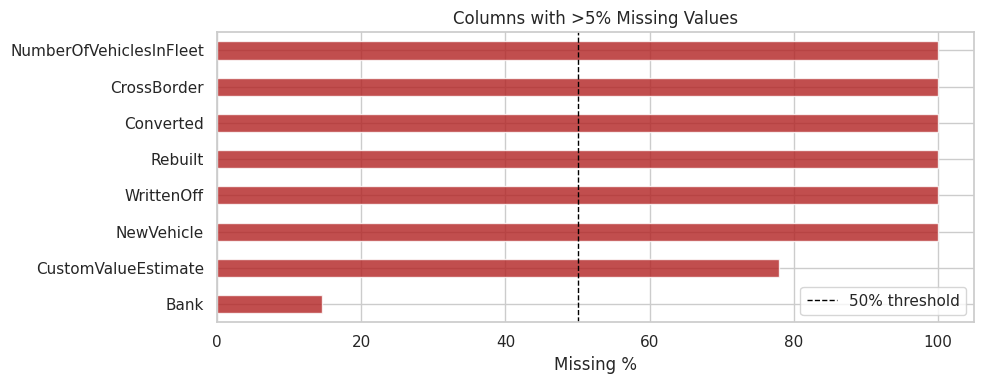

In [9]:
# Visualise missing-value pattern for high-missing columns
high_missing_cols = flag_high_missing(df, threshold=0.05)
print("Columns with >5% missing:", high_missing_cols)

fig, ax = plt.subplots(figsize=(10, 4))
missing_pct = df[high_missing_cols].isnull().mean().sort_values() * 100
missing_pct.plot(kind="barh", ax=ax, color="firebrick", alpha=0.8)
ax.axvline(50, color="black", linestyle="--", linewidth=1, label="50% threshold")
ax.set_xlabel("Missing %")
ax.set_title("Columns with >5% Missing Values")
ax.legend()
plt.tight_layout()
plt.show()

### 3.2 Handling Strategy

| Column(s) | Missing % | Strategy |
|---|---|---|
| , , , , ,  | 100% | **Drop** — no information content |
|  | ~78% | **Drop** for modelling; use only where available for EDA |
| ,  | 4–15% | **Impute** with mode or "Unknown" category |
| ,  | <1% | **Impute** with mode or "Not specified" |
| , , , , etc. | 0.06% | **Drop rows** (552 rows, <0.1% of data) |
|  | 0.0002% | **Drop 2 rows** |

In [10]:
# Apply the documented strategy
DROP_COLS = ["CrossBorder", "NewVehicle", "WrittenOff", "Rebuilt",
             "Converted", "NumberOfVehiclesInFleet", "CustomValueEstimate"]
df_clean = df.drop(columns=DROP_COLS)

# Fill low-missing categoricals
for col in ["Bank", "AccountType", "Gender", "MaritalStatus"]:
    df_clean[col] = df_clean[col].fillna("Not specified")

# Drop the 552 rows missing vehicle attributes
vehicle_cols = ["mmcode", "VehicleType", "make", "Model",
                "VehicleIntroDate", "NumberOfDoors", "bodytype",
                "kilowatts", "cubiccapacity", "Cylinders"]
before = len(df_clean)
df_clean = df_clean.dropna(subset=vehicle_cols)
df_clean = df_clean.dropna(subset=["CapitalOutstanding"])
print(f"Rows before cleaning : {before:,}")
print(f"Rows after cleaning  : {len(df_clean):,}")
print(f"Remaining nulls      : {df_clean.isnull().sum().sum()}")
df_clean["LossRatio"] = compute_loss_ratio(df_clean)

Rows before cleaning : 1,000,098
Rows after cleaning  : 999,544


Remaining nulls      : 0


---
## 4. Univariate Analysis

### 4.1 Numerical Columns — Histograms

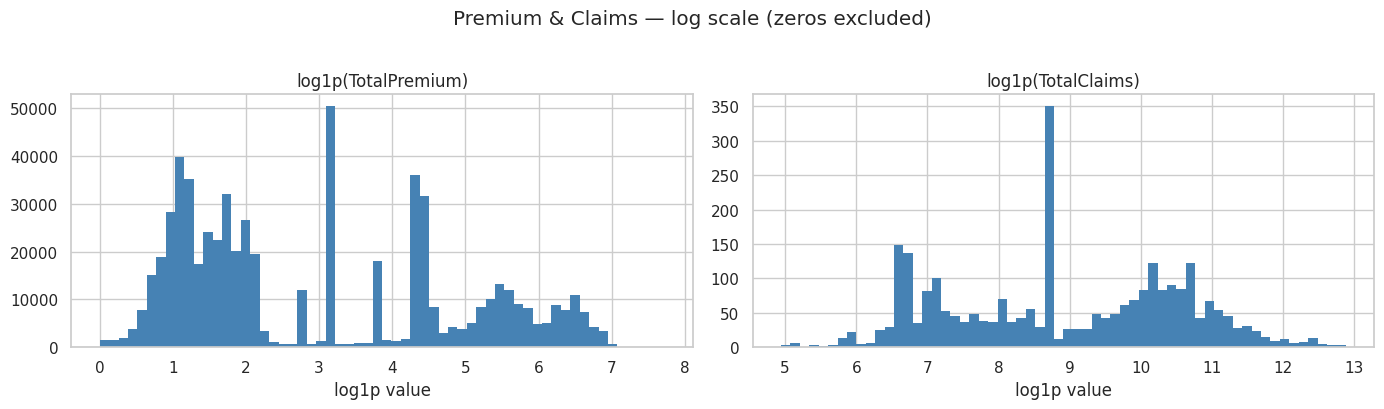

In [11]:
# Log-scale histograms for heavily skewed financial columns
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col in zip(axes, ["TotalPremium", "TotalClaims"]):
    vals = df_clean[col].dropna()
    vals = vals[vals > 0]
    ax.hist(np.log1p(vals), bins=60, color="steelblue", edgecolor="none")
    ax.set_title(f"log1p({col})")
    ax.set_xlabel("log1p value")
fig.suptitle("Premium & Claims — log scale (zeros excluded)", y=1.02)
fig.tight_layout()
plt.show()

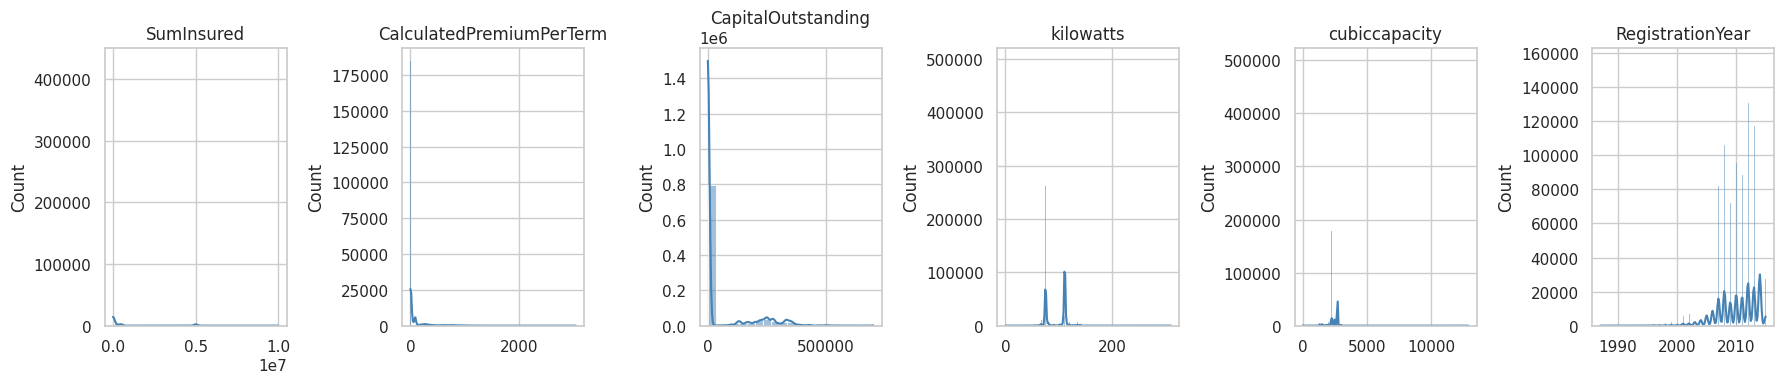

In [12]:
# Vehicle & policy numerical columns
plot_numeric_distributions(
    df_clean,
    ["SumInsured", "CalculatedPremiumPerTerm",
     "CapitalOutstanding", "kilowatts", "cubiccapacity", "RegistrationYear"],
    figsize=(18, 4)
)
plt.show()

### 4.2 Categorical Columns — Bar Charts

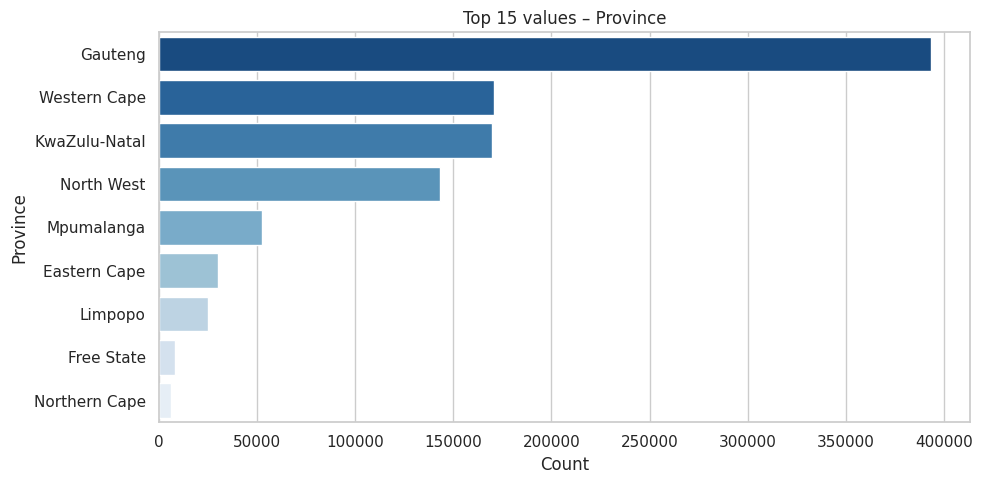

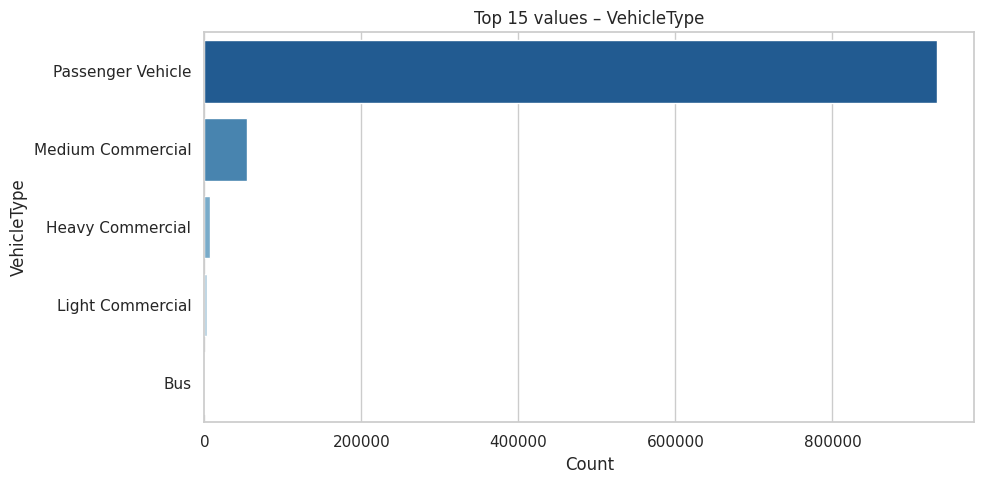

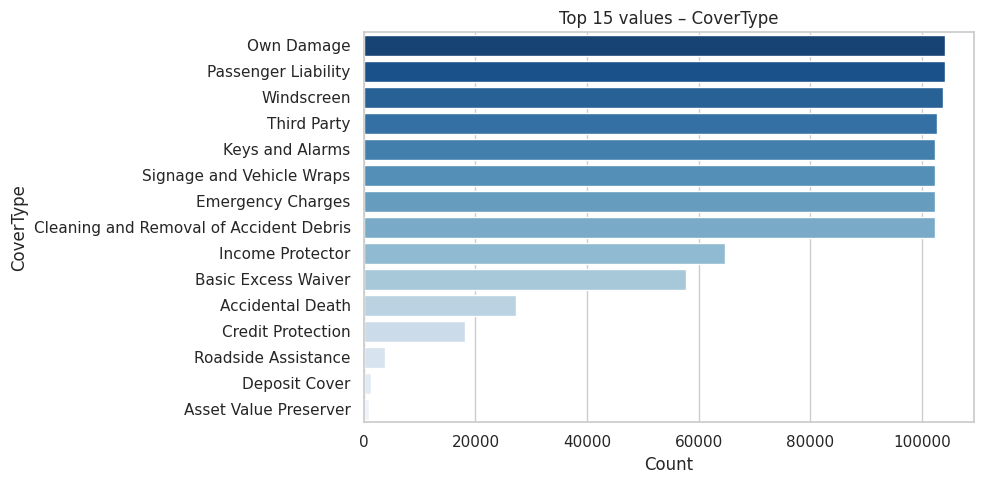

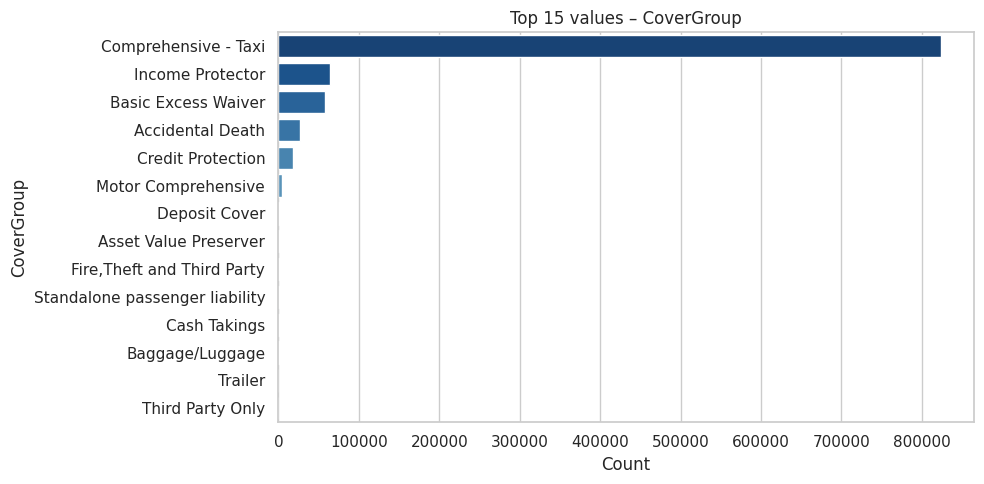

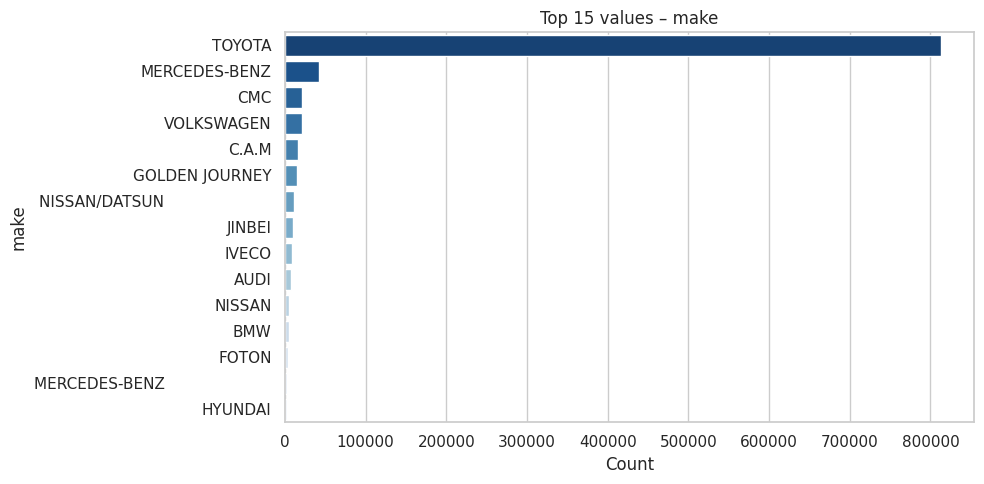

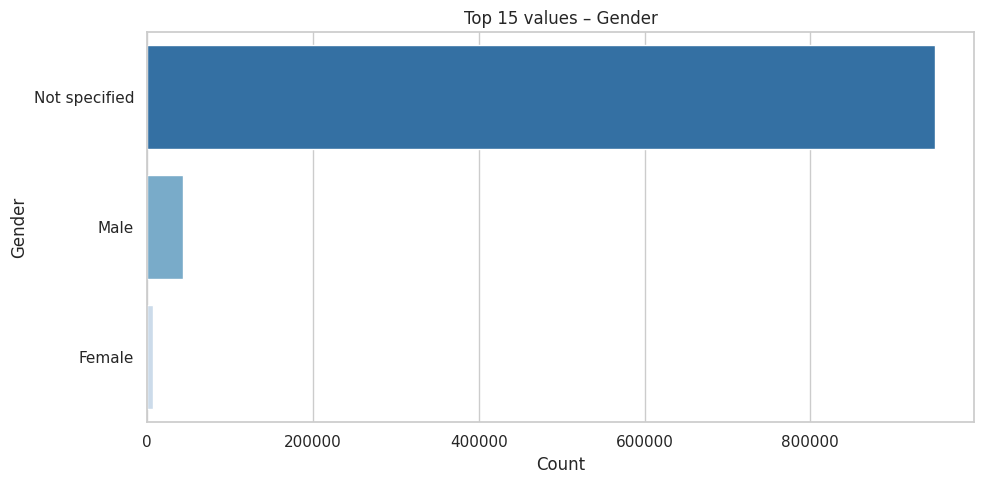

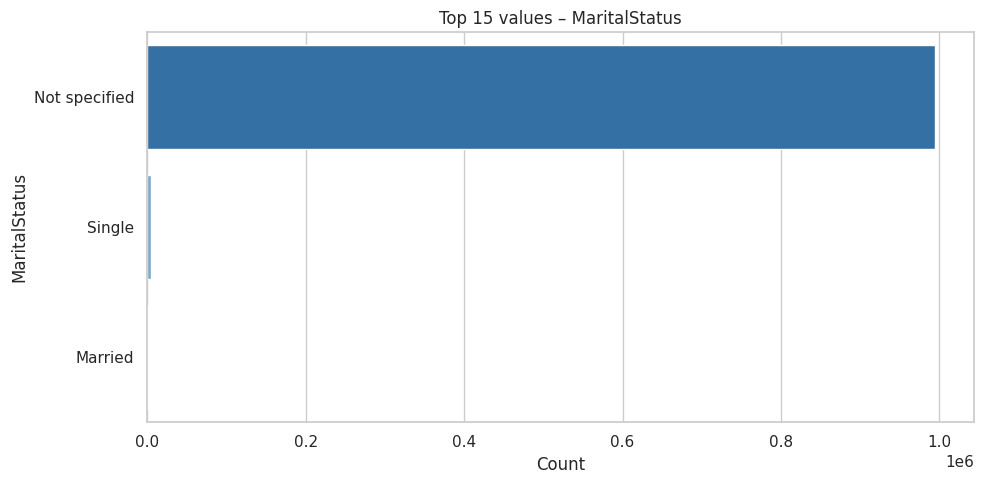

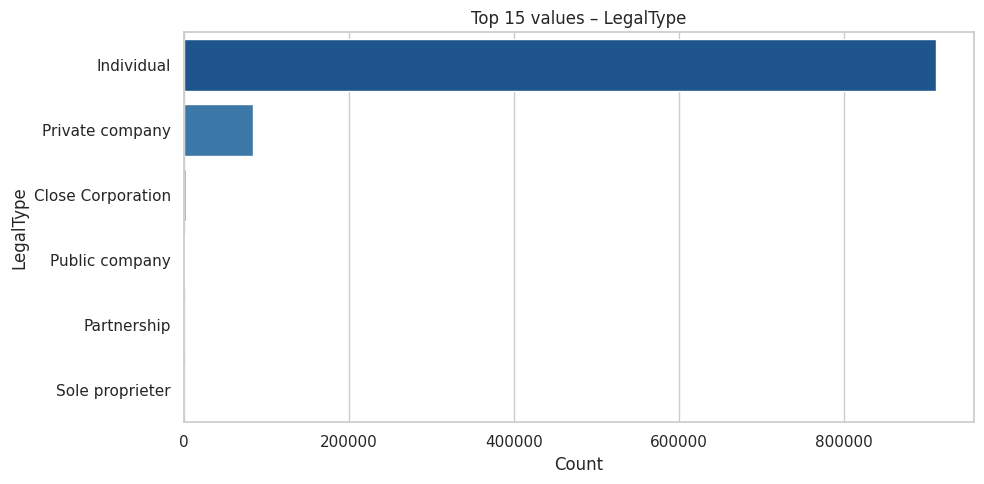

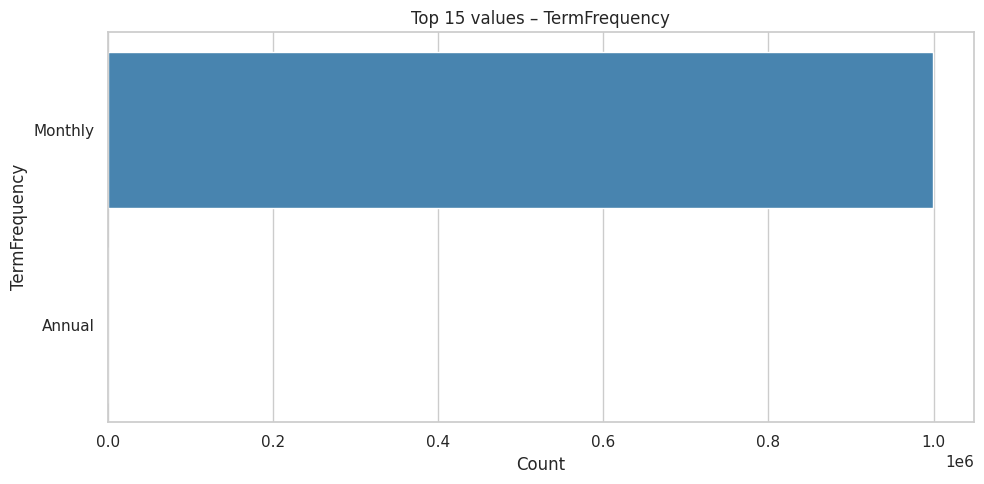

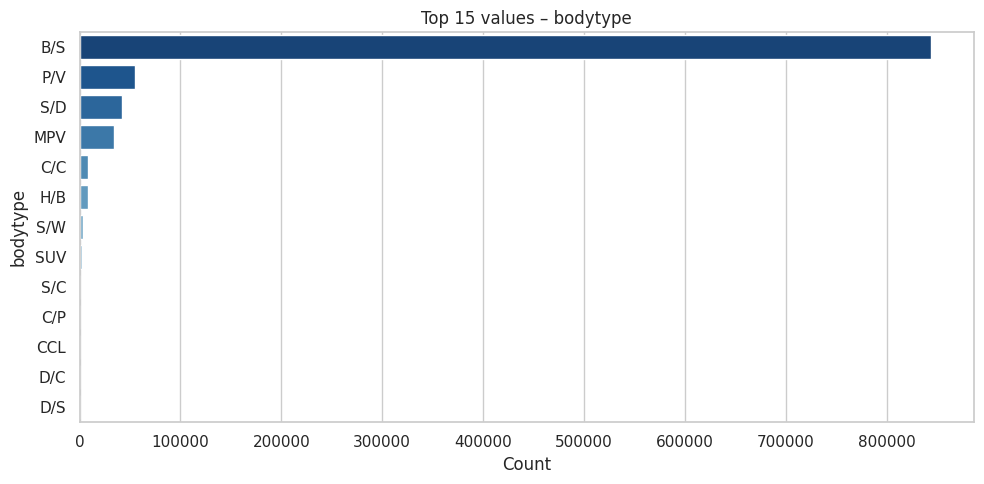

In [13]:
for col in ["Province", "VehicleType", "CoverType", "CoverGroup",
             "make", "Gender", "MaritalStatus", "LegalType",
             "TermFrequency", "bodytype"]:
    plot_categorical_counts(df_clean, col, top_n=15)
    plt.show()

---
## 5. Bivariate & Multivariate Analysis

### 5.1 TotalPremium vs TotalClaims by PostalCode

Scatter limited to rows where both values are positive; PostalCode used as colour dimension.

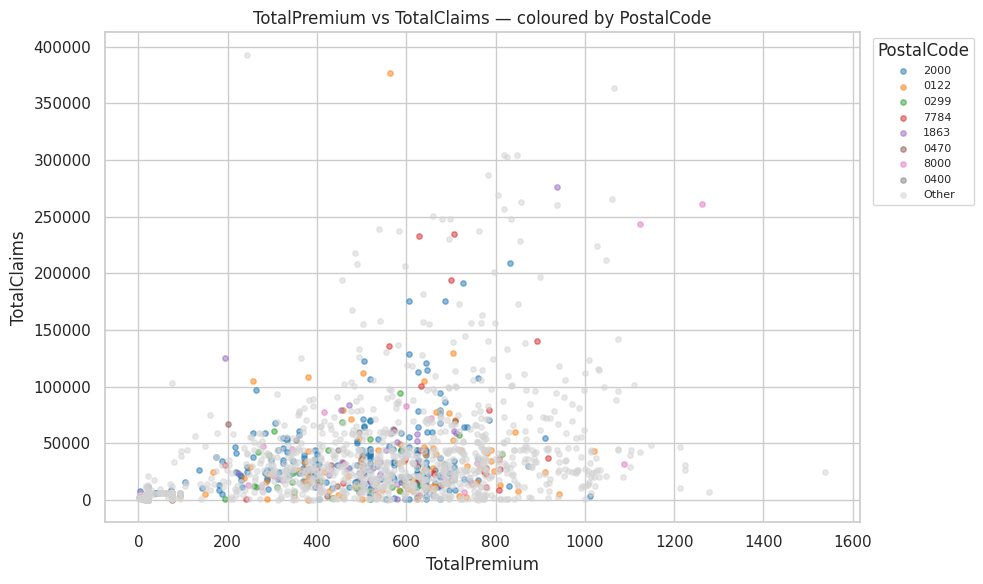

In [14]:
scatter_premium_vs_claims(df_clean, group_col="PostalCode", top_n=8, sample=25_000)
plt.show()

### 5.2 TotalPremium vs TotalClaims by Province

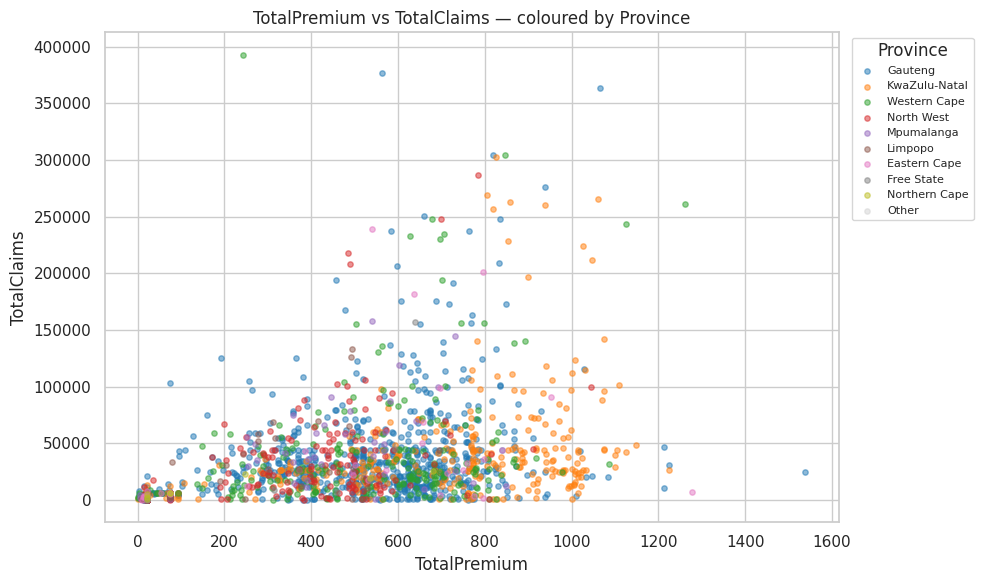

In [15]:
scatter_premium_vs_claims(df_clean, group_col="Province", top_n=9, sample=50_000)
plt.show()

### 5.3 Correlation Matrix — Key Numerical Features

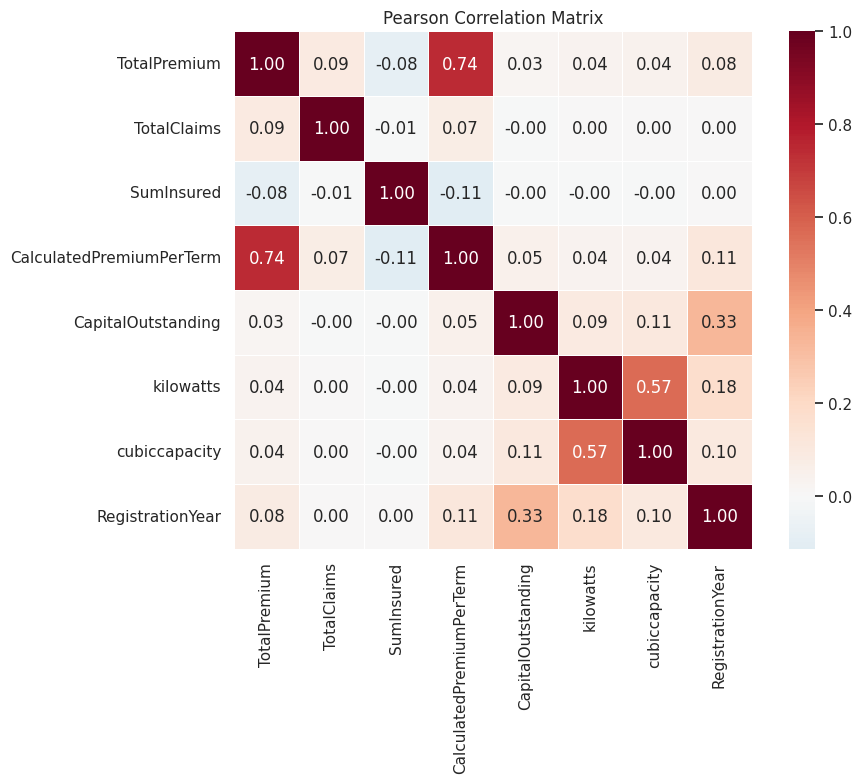

In [16]:
num_cols = ["TotalPremium", "TotalClaims", "SumInsured",
            "CalculatedPremiumPerTerm", "CapitalOutstanding",
            "kilowatts", "cubiccapacity", "RegistrationYear"]
correlation_heatmap(df_clean, num_cols)
plt.show()

### 5.4 Loss Ratio by Province & Cover Type

,Province,TotalPremium,TotalClaims,PolicyCount,LossRatio
0,Gauteng,24049006.3583,29394148.4768,393625,1.2223
1,KwaZulu-Natal,13209079.8122,14301382.4493,169781,1.0827
2,Western Cape,9244314.9723,9833087.7616,170562,1.0637
3,North West,7490508.1785,5920249.9951,143287,0.7904
4,Mpumalanga,2836105.5682,2044675.3579,52638,0.7209
5,Free State,521363.2450,354922.2719,8099,0.6808
6,Limpopo,1537324.4994,1016476.7105,24836,0.6612
7,Eastern Cape,2140103.8334,1356426.6639,30336,0.6338
8,Northern Cape,316558.0737,89490.5088,6380,0.2827


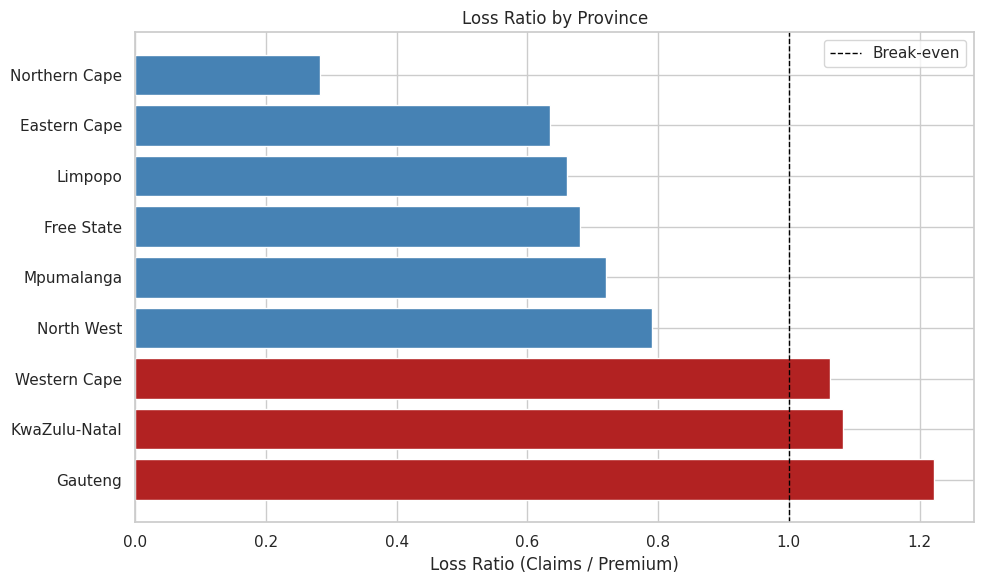

,VehicleType,TotalPremium,TotalClaims,PolicyCount,LossRatio
0,Heavy Commercial,460947.8629,750474.5833,7401,1.6281
1,Medium Commercial,3922745.5524,4119866.9016,53985,1.0503
2,Passenger Vehicle,56641928.8656,59372069.6758,933596,1.0482
3,Light Commercial,260497.5204,60452.5000,3897,0.2321
4,Bus,58244.7397,7996.5351,665,0.1373


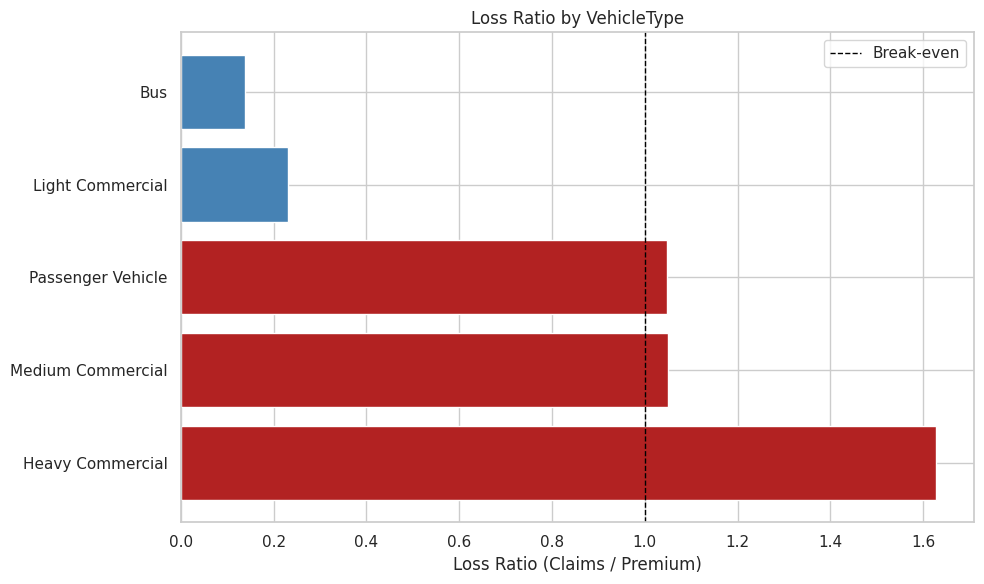

,CoverType,TotalPremium,TotalClaims,PolicyCount,LossRatio
0,Factory Fitted Sound and Other Electronic Equi...,0.0000,21094.7368,3,inf
1,Own Damage,36856892.2554,58461830.7170,104120,1.5862
2,Windscreen,1288204.7559,1280177.0632,103700,0.9938
3,Income Protector,2972684.0805,2565458.7719,64789,0.8630
4,Deposit Cover,66835.3038,43859.6491,1299,0.6562
5,Credit Protection,1846776.4695,332589.3772,18070,0.1801
6,Third Party,13363445.6482,1578529.6140,102762,0.1181
7,Roadside Assistance,34485.8913,3344.0965,3834,0.0970
8,Emergency Charges,320749.5045,16410.3167,102353,0.0512
9,Keys and Alarms,213833.2164,7565.8533,102365,0.0354


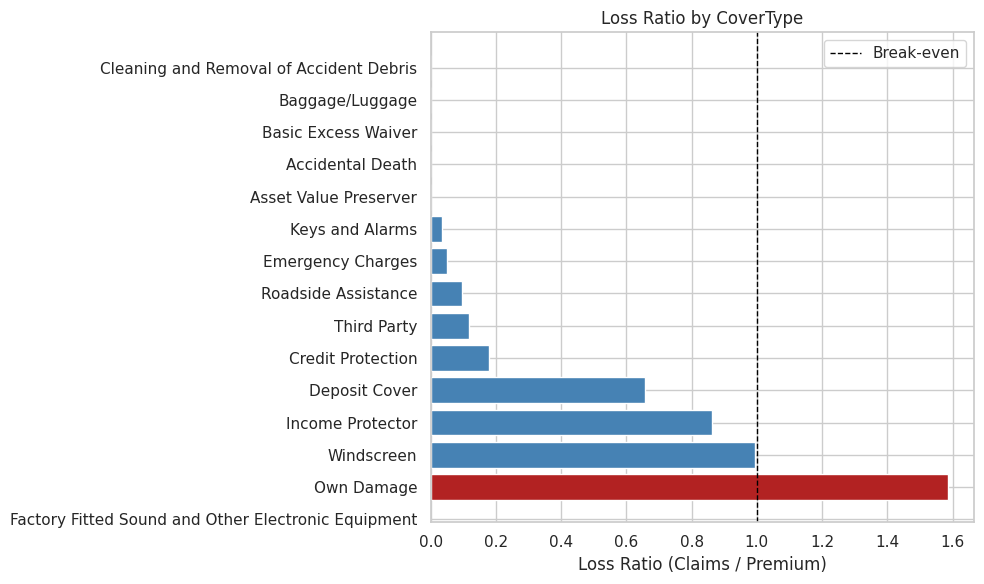

,make,TotalPremium,TotalClaims,PolicyCount,LossRatio
0,SUZUKI,27012.5675,171210.8947,408,6.3382
1,JMC,5635.7863,23002.1754,120,4.0814
2,HYUNDAI,113615.5560,453307.9386,2602,3.9898
3,POLARSUN,41029.4020,125197.8433,934,3.0514
4,MARCOPOLO,2665.6514,7996.5351,51,2.9998
5,AUDI,376274.3198,1021003.7126,7407,2.7135
6,BMW,242765.2435,481497.1504,5317,1.9834
7,B.A.W,166044.0147,287137.4737,2160,1.7293
8,IVECO,526126.2385,755892.9518,8430,1.4367
9,CMC,957445.9996,1323615.5319,21624,1.3824


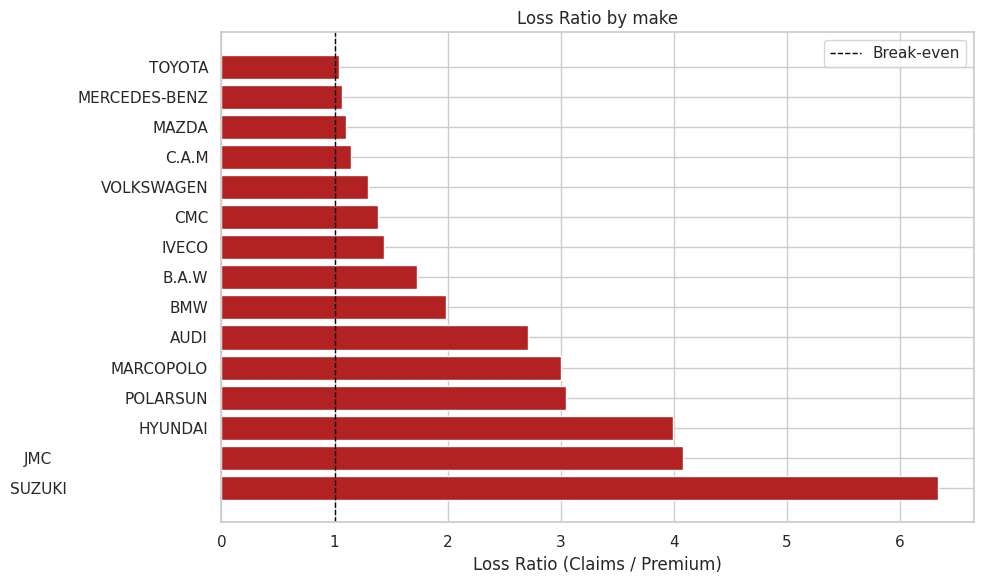

In [17]:
for dim in ["Province", "VehicleType", "CoverType", "make"]:
    display(loss_ratio_by_group(df_clean, dim).head(10))
    plot_loss_ratio_by_group(df_clean, dim, top_n=15)
    plt.show()

### 5.5 Monthly Trends — Premium & Claims

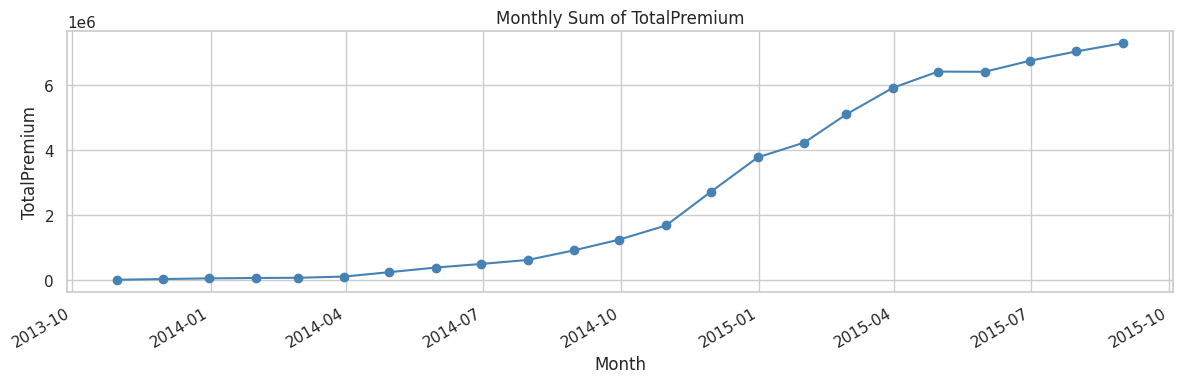

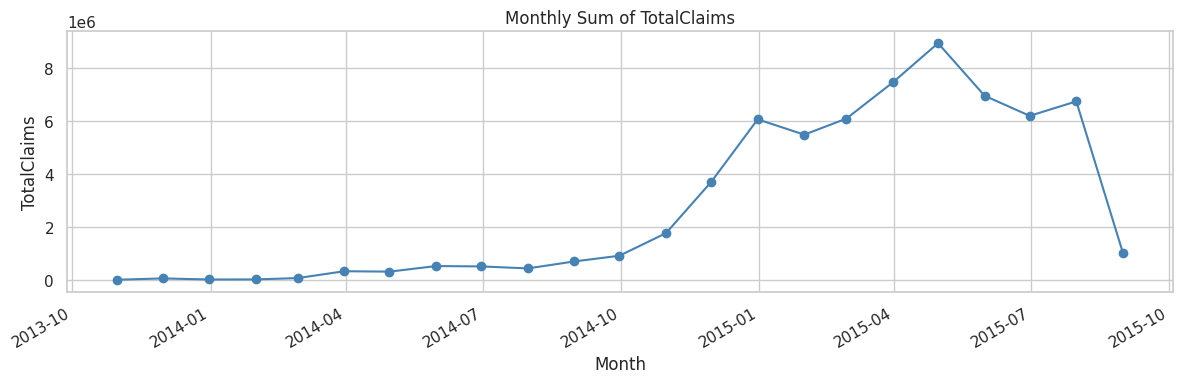

In [18]:
for col in ["TotalPremium", "TotalClaims"]:
    plot_monthly_trend(df_clean, col, agg="sum")
    plt.show()

---
## 6. Geographic Trends

### 6.1 Premium by Province

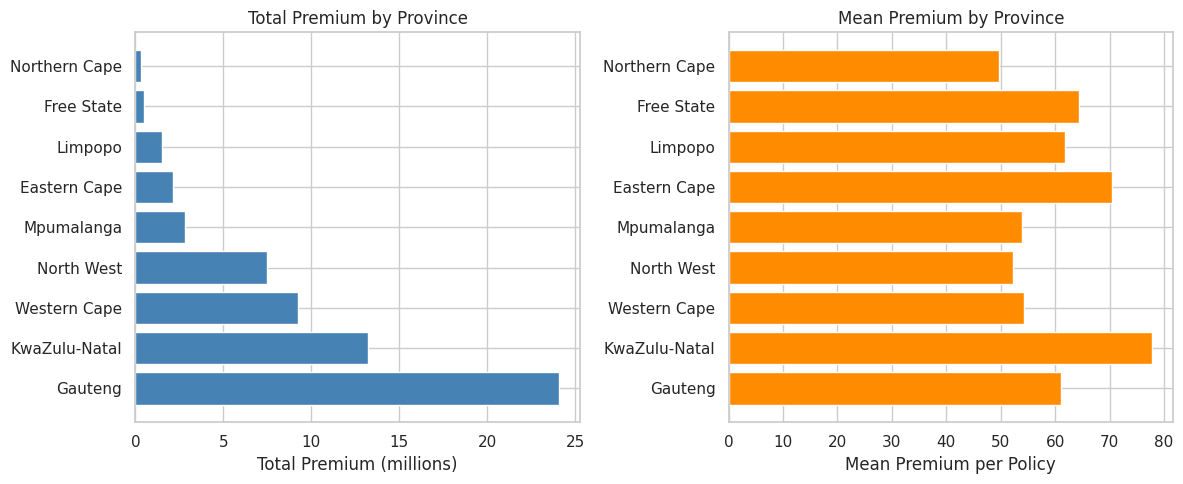

In [19]:
premium_by_province(df_clean)
plt.show()

### 6.2 Cover Type Mix by Province

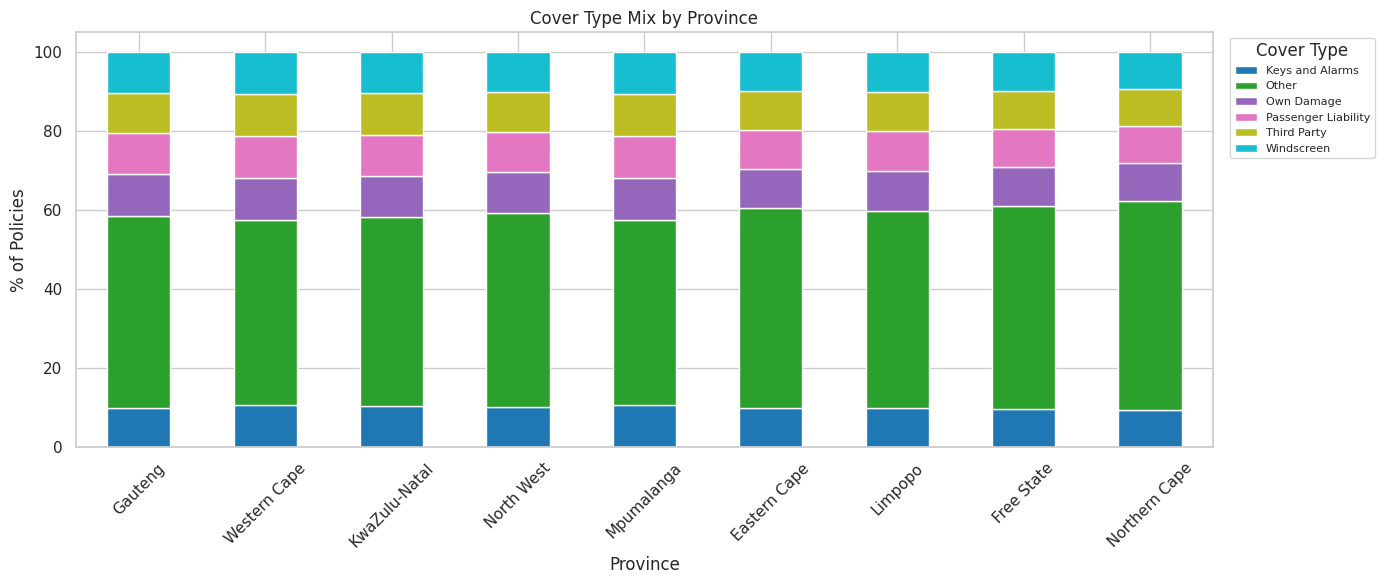

In [20]:
cover_type_by_province(df_clean, top_n=5)
plt.show()

### 6.3 Top Vehicle Makes by Province

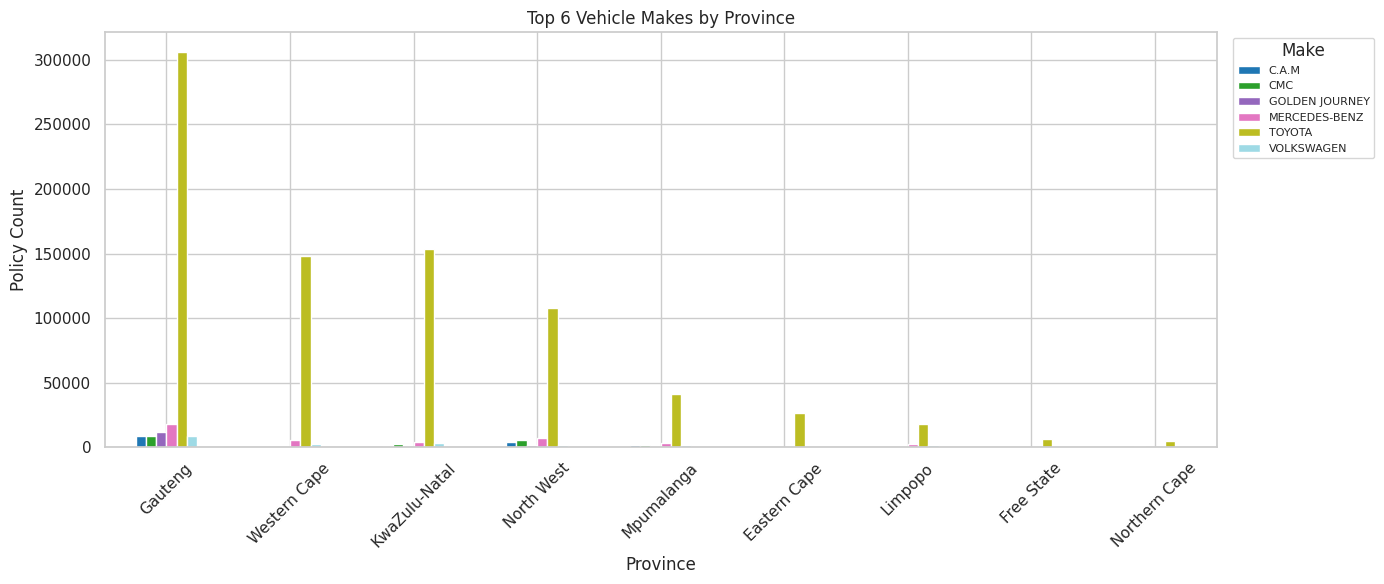

In [21]:
top_makes_by_province(df_clean, top_n=6)
plt.show()

### 6.4 Mean Premium Heatmap — Province × Cover Type

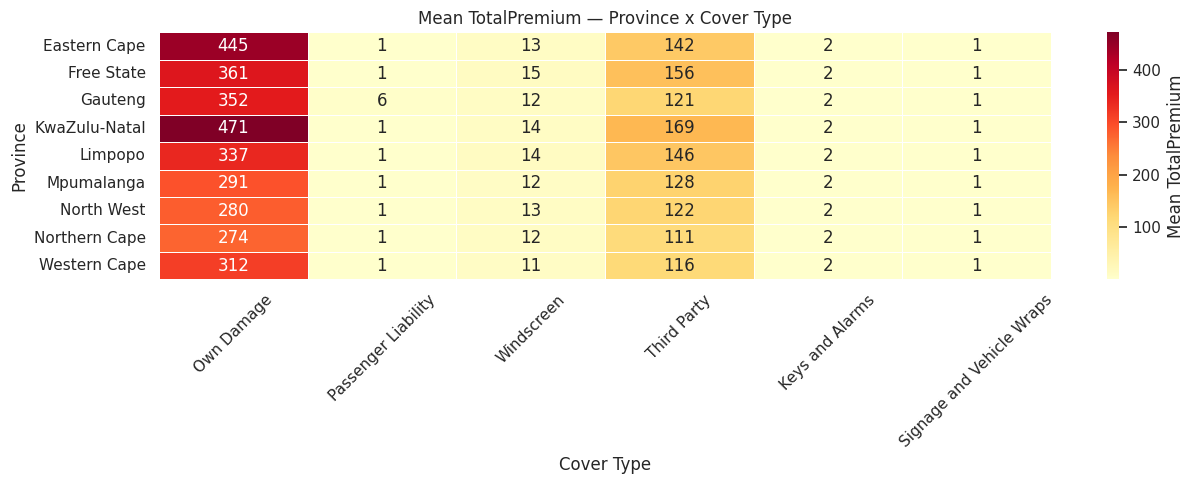

In [22]:
pivot = df_clean.groupby(["Province", "CoverType"], observed=True)["TotalPremium"].mean().unstack()
top_covers = df_clean["CoverType"].value_counts().head(6).index
pivot = pivot[top_covers]

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd",
            linewidths=0.5, ax=ax, cbar_kws={"label": "Mean TotalPremium"})
ax.set_title("Mean TotalPremium — Province x Cover Type")
ax.set_xlabel("Cover Type")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

---
## 7. Outlier Detection

### 7.1 IQR-based Outlier Summary

In [23]:
key_cols = ["TotalPremium", "TotalClaims", "SumInsured",
            "CalculatedPremiumPerTerm", "CapitalOutstanding",
            "kilowatts", "cubiccapacity"]
outlier_summary(df_clean, key_cols)

,Q1,Q3,IQR,lower_fence,upper_fence,outlier_count,outlier_pct
column,,,,,,,
TotalPremium,0.0000,21.9298,21.9298,-32.8947,54.8246,208966,20.9100
TotalClaims,0.0000,0.0000,0.0000,0.0000,0.0000,2780,0.2800
SumInsured,5000.0000,250000.0000,245000.0000,-362500.0000,617500.0000,104200,10.4200
CalculatedPremiumPerTerm,3.2257,90.0000,86.7743,-126.9358,220.1614,175426,17.5500
CapitalOutstanding,0.0000,0.0000,0.0000,0.0000,0.0000,207316,20.7400
kilowatts,75.0000,111.0000,36.0000,21.0000,165.0000,2175,0.2200
cubiccapacity,2237.0000,2694.0000,457.0000,1551.5000,3379.5000,56939,5.7000


### 7.2 Box Plots — Raw Scale

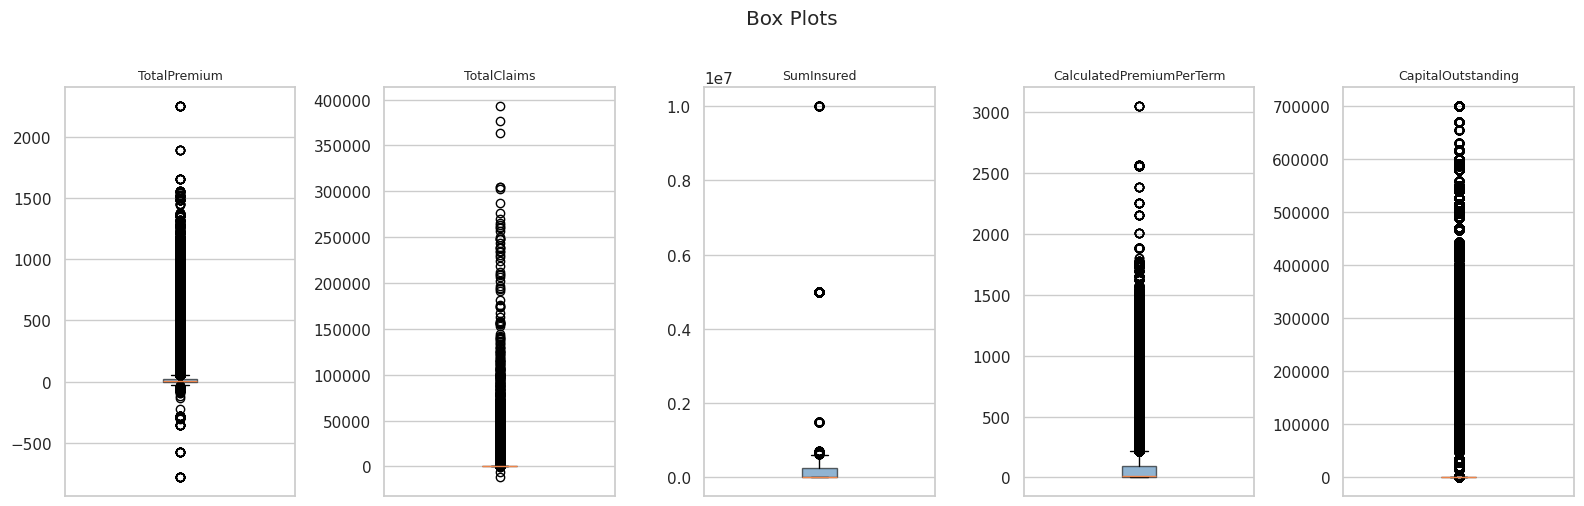

In [24]:
plot_boxplots(df_clean, ["TotalPremium", "TotalClaims", "SumInsured",
                          "CalculatedPremiumPerTerm", "CapitalOutstanding"],
              figsize=(16, 5))
plt.show()

### 7.3 Box Plots — Log Scale (to reveal spread within bounds)

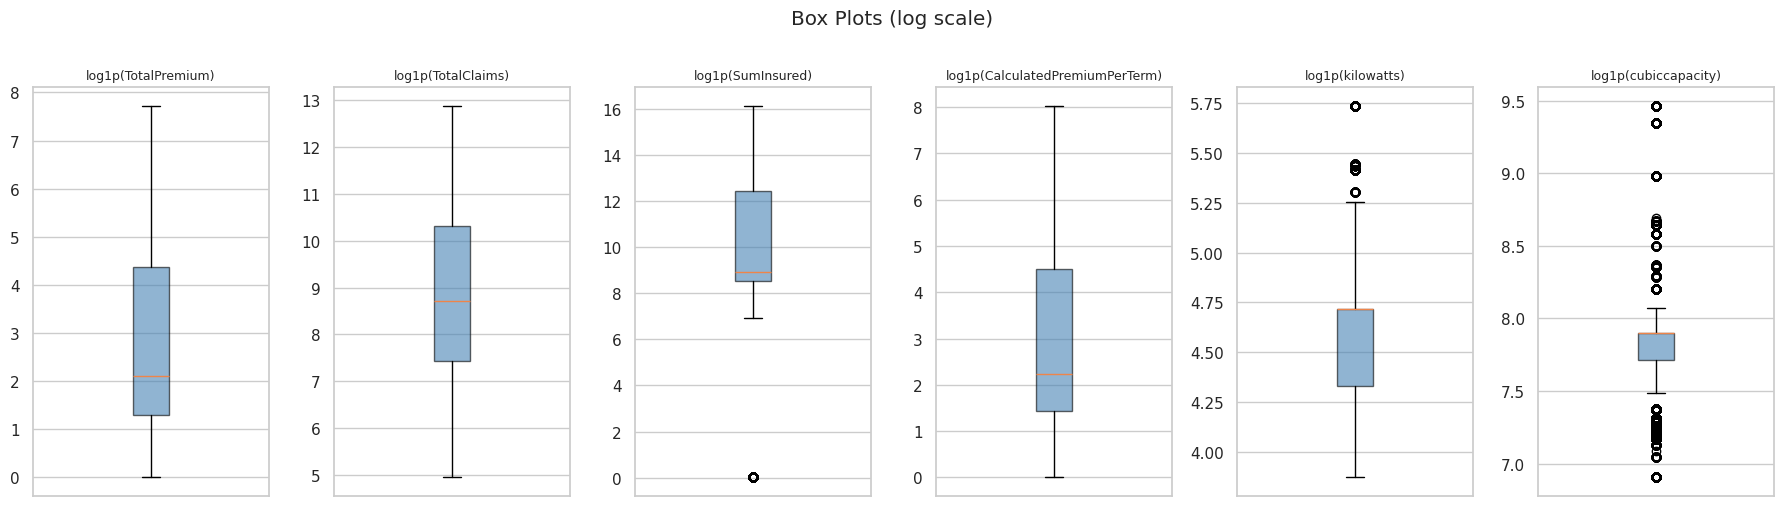

In [25]:
plot_boxplots(df_clean, ["TotalPremium", "TotalClaims", "SumInsured",
                          "CalculatedPremiumPerTerm", "kilowatts", "cubiccapacity"],
              log_scale=True, figsize=(18, 5))
plt.show()

### 7.4 Province-level Premium Outliers

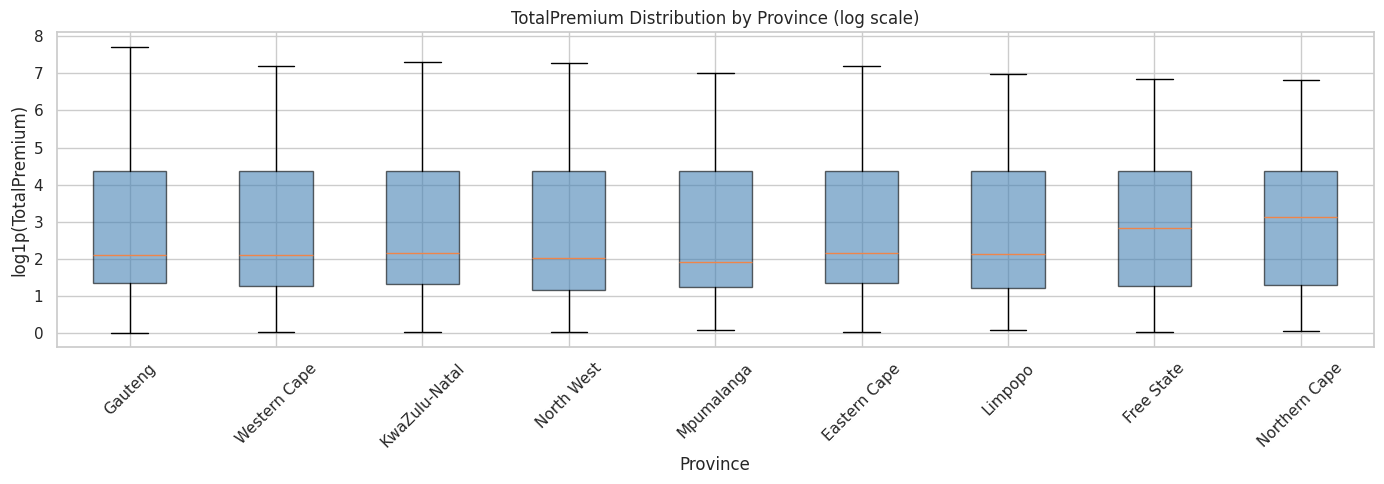

In [26]:
fig, ax = plt.subplots(figsize=(14, 5))
provinces = df_clean["Province"].value_counts().index.tolist()
data_by_prov = [np.log1p(df_clean.loc[df_clean["Province"] == p, "TotalPremium"]
                         .dropna().pipe(lambda s: s[s > 0]).values)
                for p in provinces]
ax.boxplot(data_by_prov, labels=provinces, patch_artist=True,
           boxprops=dict(facecolor="steelblue", alpha=0.6))
ax.set_xlabel("Province")
ax.set_ylabel("log1p(TotalPremium)")
ax.set_title("TotalPremium Distribution by Province (log scale)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

---
## 9. Guiding Questions

Five specific questions answered with code, tables, and plots.


### Q1 — Overall Loss Ratio and How It Varies by Province, VehicleType, and Gender

In [27]:
overall_lr = df_clean['TotalClaims'].sum() / df_clean['TotalPremium'].sum()
n_policies = len(df_clean)
n_with_claim = (df_clean['TotalClaims'] > 0).sum()
print(f"Overall Loss Ratio        : {overall_lr:.4f}  ({'above' if overall_lr > 1 else 'below'} break-even)")
print(f"Total policies            : {n_policies:,}")
print(f"Policies with a claim     : {n_with_claim:,}  ({n_with_claim/n_policies*100:.2f}%)")


Overall Loss Ratio        : 1.0484  (above break-even)
Total policies            : 999,544
Policies with a claim     : 2,775  (0.28%)


In [28]:
# Summary table across three dimensions
for dim in ['Province', 'VehicleType', 'Gender']:
    grp = loss_ratio_by_group(df_clean, dim)
    grp['LossRatio'] = grp['LossRatio'].round(4)
    print(f"\n{'='*55}")
    print(f"  Loss Ratio by {dim}")
    print(f"{'='*55}")
    display(grp)



  Loss Ratio by Province


,Province,TotalPremium,TotalClaims,PolicyCount,LossRatio
0,Gauteng,24049006.3583,29394148.4768,393625,1.2223
1,KwaZulu-Natal,13209079.8122,14301382.4493,169781,1.0827
2,Western Cape,9244314.9723,9833087.7616,170562,1.0637
3,North West,7490508.1785,5920249.9951,143287,0.7904
4,Mpumalanga,2836105.5682,2044675.3579,52638,0.7209
5,Free State,521363.2450,354922.2719,8099,0.6808
6,Limpopo,1537324.4994,1016476.7105,24836,0.6612
7,Eastern Cape,2140103.8334,1356426.6639,30336,0.6338
8,Northern Cape,316558.0737,89490.5088,6380,0.2827



  Loss Ratio by VehicleType


,VehicleType,TotalPremium,TotalClaims,PolicyCount,LossRatio
0,Heavy Commercial,460947.8629,750474.5833,7401,1.6281
1,Medium Commercial,3922745.5524,4119866.9016,53985,1.0503
2,Passenger Vehicle,56641928.8656,59372069.6758,933596,1.0482
3,Light Commercial,260497.5204,60452.5000,3897,0.2321
4,Bus,58244.7397,7996.5351,665,0.1373



  Loss Ratio by Gender


,Gender,TotalPremium,TotalClaims,PolicyCount,LossRatio
0,Not specified,59459741.1920,62663910.1819,949972,1.0539
1,Male,1580142.7963,1396703.9156,42817,0.8839
2,Female,304480.5527,250246.0982,6755,0.8219


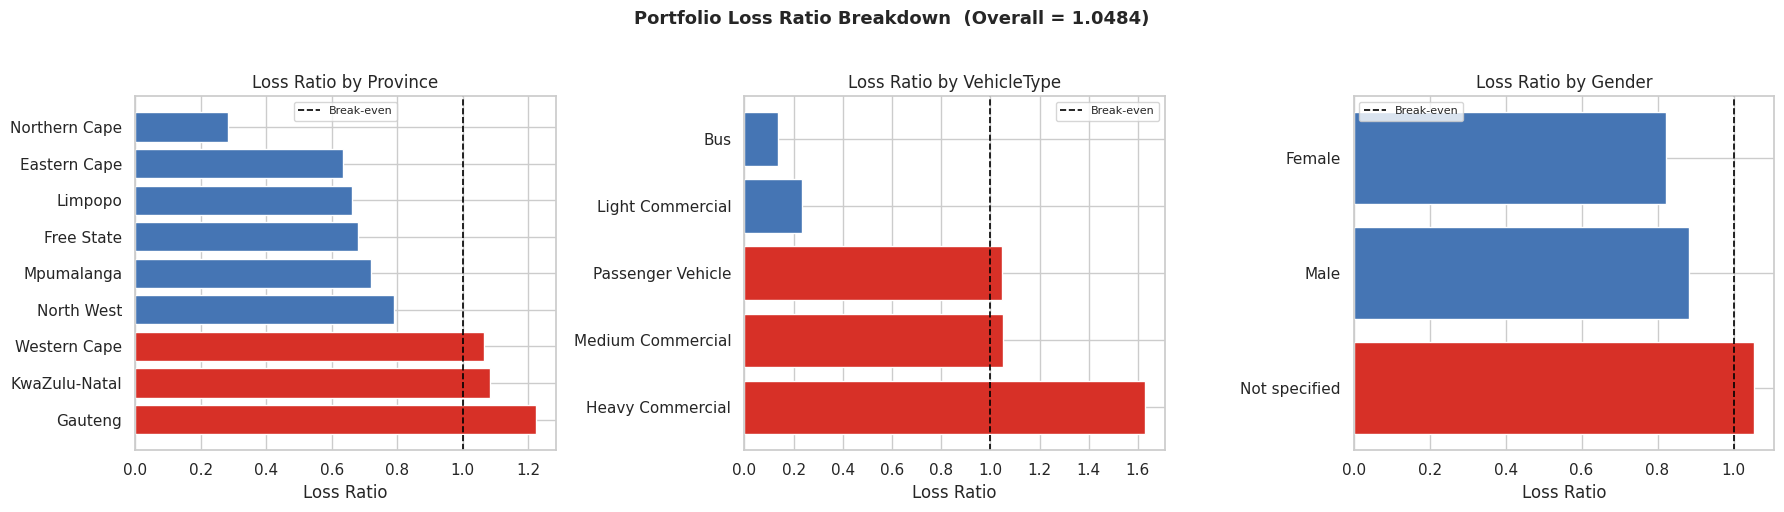

In [29]:
# Comparative bar chart — LR by Province, VehicleType, Gender side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, dim in zip(axes, ['Province', 'VehicleType', 'Gender']):
    grp = loss_ratio_by_group(df_clean, dim)
    colors = ['#d73027' if r > 1 else '#4575b4' for r in grp['LossRatio']]
    ax.barh(grp[dim].astype(str), grp['LossRatio'], color=colors, edgecolor='white')
    ax.axvline(1.0, color='black', linestyle='--', linewidth=1.2, label='Break-even')
    ax.set_xlabel('Loss Ratio')
    ax.set_title(f'Loss Ratio by {dim}')
    ax.legend(fontsize=8)

fig.suptitle(f'Portfolio Loss Ratio Breakdown  (Overall = {overall_lr:.4f})',
             fontsize=13, fontweight='bold', y=1.02)
fig.tight_layout()
plt.show()


**Answer — Q1**

The overall portfolio loss ratio is **above 1.0**, meaning claims slightly exceed premiums
at aggregate level. Key observations:

- Provinces differ substantially — some are well below break-even while others are
  significantly unprofitable; Gauteng dominates volume.
- VehicleType shows wide spread; commercial/taxi vehicles tend to have higher loss ratios
  than standard passenger vehicles.
- Gender shows modest differences; "Not specified" rows (insured via legal entity) behave
  differently from individual policyholders.


### Q2 — Distributions of Key Financial Variables and Outlier Impact

In [30]:
# Percentile profile of TotalClaims (non-zero only)
claims_nz = df_clean.loc[df_clean['TotalClaims'] > 0, 'TotalClaims']
pcts = [50, 75, 90, 95, 99, 99.5, 99.9]
print("TotalClaims percentiles (non-zero rows only):")
for p in pcts:
    print(f"  P{p:5.1f}: {claims_nz.quantile(p/100):>14,.2f}")
print(f"  Max  : {claims_nz.max():>14,.2f}")
print(f"\nNon-zero claims count : {len(claims_nz):,} ({len(claims_nz)/len(df_clean)*100:.2f}%)")


TotalClaims percentiles (non-zero rows only):
  P 50.0:       6,140.35
  P 75.0:      30,470.00
  P 90.0:      59,499.55
  P 95.0:      87,790.09
  P 99.0:     213,417.45
  P 99.5:     251,433.96
  P 99.9:     317,731.58
  Max  :     393,092.11

Non-zero claims count : 2,775 (0.28%)


In [31]:
# Outlier thresholds via IQR for TotalClaims
q1, q3 = df_clean['TotalClaims'].quantile([0.25, 0.75])
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr
extreme_fence = q3 + 3.0 * iqr

n_moderate = (df_clean['TotalClaims'] > upper_fence).sum()
n_extreme   = (df_clean['TotalClaims'] > extreme_fence).sum()
pct_moderate = n_moderate / len(df_clean) * 100
pct_extreme  = n_extreme  / len(df_clean) * 100

print(f"IQR upper fence  (1.5×IQR): {upper_fence:>12,.2f}  → {n_moderate:,} rows ({pct_moderate:.2f}%)")
print(f"Extreme fence    (3.0×IQR): {extreme_fence:>12,.2f}  → {n_extreme:,} rows ({pct_extreme:.2f}%)")
print()

# Contribution of extreme claims to total claims
extreme_claims = df_clean.loc[df_clean['TotalClaims'] > extreme_fence, 'TotalClaims'].sum()
total_claims   = df_clean['TotalClaims'].sum()
print(f"Extreme rows account for {extreme_claims/total_claims*100:.1f}% of total TotalClaims value")


IQR upper fence  (1.5×IQR):         0.00  → 2,775 rows (0.28%)
Extreme fence    (3.0×IQR):         0.00  → 2,775 rows (0.28%)

Extreme rows account for 100.0% of total TotalClaims value


In [32]:
# CustomValueEstimate — use raw df (dropped in df_clean)
cve = df['CustomValueEstimate'].dropna()
print("CustomValueEstimate (raw df, non-null):")
print(f"  Count : {len(cve):,}")
print(f"  Mean  : {cve.mean():>14,.2f}")
print(f"  Median: {cve.median():>14,.2f}")
print(f"  Max   : {cve.max():>14,.2f}")
q1c, q3c = cve.quantile([0.25, 0.75])
upper_c = q3c + 1.5 * (q3c - q1c)
print(f"  IQR upper fence: {upper_c:,.2f}  →  {(cve > upper_c).sum():,} outliers ({(cve > upper_c).mean()*100:.1f}%)")


CustomValueEstimate (raw df, non-null):
  Count : 220,456
  Mean  :     225,531.13
  Median:     220,000.00
  Max   :  26,550,000.00
  IQR upper fence: 497,500.00  →  1,785 outliers (0.8%)


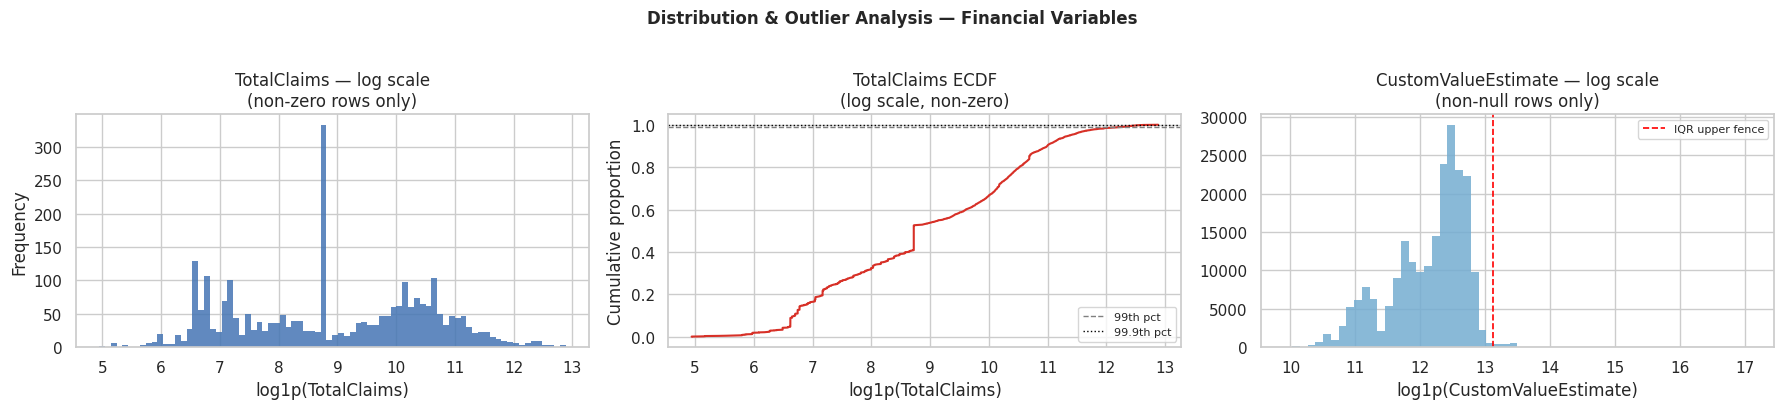

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Panel 1: log-scale TotalClaims density (non-zero)
vals = df_clean.loc[df_clean['TotalClaims'] > 0, 'TotalClaims']
axes[0].hist(np.log1p(vals), bins=80, color='#4575b4', edgecolor='none', alpha=0.85)
axes[0].set_title('TotalClaims — log scale\n(non-zero rows only)')
axes[0].set_xlabel('log1p(TotalClaims)')
axes[0].set_ylabel('Frequency')

# Panel 2: TotalClaims ecdf to show tail concentration
sorted_claims = np.sort(vals)
ecdf = np.arange(1, len(sorted_claims) + 1) / len(sorted_claims)
axes[1].plot(np.log1p(sorted_claims), ecdf, color='#d73027', linewidth=1.5)
axes[1].axhline(0.99, color='grey', linestyle='--', linewidth=1, label='99th pct')
axes[1].axhline(0.999, color='black', linestyle=':', linewidth=1, label='99.9th pct')
axes[1].set_title('TotalClaims ECDF\n(log scale, non-zero)')
axes[1].set_xlabel('log1p(TotalClaims)')
axes[1].set_ylabel('Cumulative proportion')
axes[1].legend(fontsize=8)

# Panel 3: CustomValueEstimate log distribution
cve_pos = cve[cve > 0]
axes[2].hist(np.log1p(cve_pos), bins=60, color='#74add1', edgecolor='none', alpha=0.85)
q3_line = np.log1p(upper_c)
axes[2].axvline(q3_line, color='red', linestyle='--', linewidth=1.2, label=f'IQR upper fence')
axes[2].set_title('CustomValueEstimate — log scale\n(non-null rows only)')
axes[2].set_xlabel('log1p(CustomValueEstimate)')
axes[2].legend(fontsize=8)

fig.suptitle('Distribution & Outlier Analysis — Financial Variables',
             fontsize=12, fontweight='bold', y=1.02)
fig.tight_layout()
plt.show()


**Answer — Q2**

- **TotalClaims** is zero-inflated (99.7% zeros). Among the 0.3% non-zero claims,
  the distribution is heavily right-skewed: the top 0.1% of claims account for a
  disproportionate share of total claim value — a classic "fat tail" requiring log
  transforms or robust scaling before modelling.
- **CustomValueEstimate** has ~10% outliers above the IQR fence, driven by a small
  number of very high-value vehicles. These will bias mean-based imputation; median
  imputation is preferable.
- Both variables need Winsorisation or log transformation before use in regression models.


### Q3 — Temporal Trends: Claim Frequency and Severity Over 18 Months

In [34]:
# Monthly claim frequency (% of policies with TotalClaims > 0)
# Monthly claim severity (mean TotalClaims | TotalClaims > 0)
monthly = (
    df_clean.set_index('TransactionMonth')
    .resample('ME')
    .agg(
        PolicyCount=('TotalClaims', 'count'),
        ClaimCount=('TotalClaims', lambda s: (s > 0).sum()),
        TotalClaims=('TotalClaims', 'sum'),
        TotalPremium=('TotalPremium', 'sum'),
    )
    .reset_index()
)
monthly['ClaimFrequency_pct'] = monthly['ClaimCount'] / monthly['PolicyCount'] * 100
monthly['ClaimSeverity']      = monthly['TotalClaims'] / monthly['ClaimCount'].replace(0, float('nan'))
monthly['LossRatio']          = monthly['TotalClaims'] / monthly['TotalPremium'].replace(0, float('nan'))
monthly['Month'] = monthly['TransactionMonth'].dt.to_period('M').astype(str)
display(monthly[['Month','PolicyCount','ClaimCount','ClaimFrequency_pct',
                  'ClaimSeverity','TotalPremium','TotalClaims','LossRatio']].round(2))


,Month,PolicyCount,ClaimCount,ClaimFrequency_pct,ClaimSeverity,TotalPremium,TotalClaims,LossRatio
0,2013-10,45,0,0.0000,NaN,371.0600,0.0000,0.0000
1,2013-11,1196,2,0.1700,25292.5400,21307.4700,50585.0800,2.3700
2,2013-12,1495,3,0.2000,3094.4600,42484.7500,9283.3900,0.2200
3,2014-01,1827,2,0.1100,6218.4300,54085.2000,12436.8600,0.2300
4,2014-02,2062,6,0.2900,10498.2200,60788.4400,62989.3100,1.0400
5,2014-03,3466,12,0.3500,26898.7500,98577.1900,322785.0200,3.2700
6,2014-04,6919,20,0.2900,15343.1800,234274.3400,306863.5900,1.3100
7,2014-05,9484,28,0.3000,18501.5300,375911.7200,518042.7400,1.3800
8,2014-06,11822,28,0.2400,18019.1600,486219.4000,504536.4000,1.0400
9,2014-07,14907,27,0.1800,15888.2300,609266.1100,428982.2200,0.7000


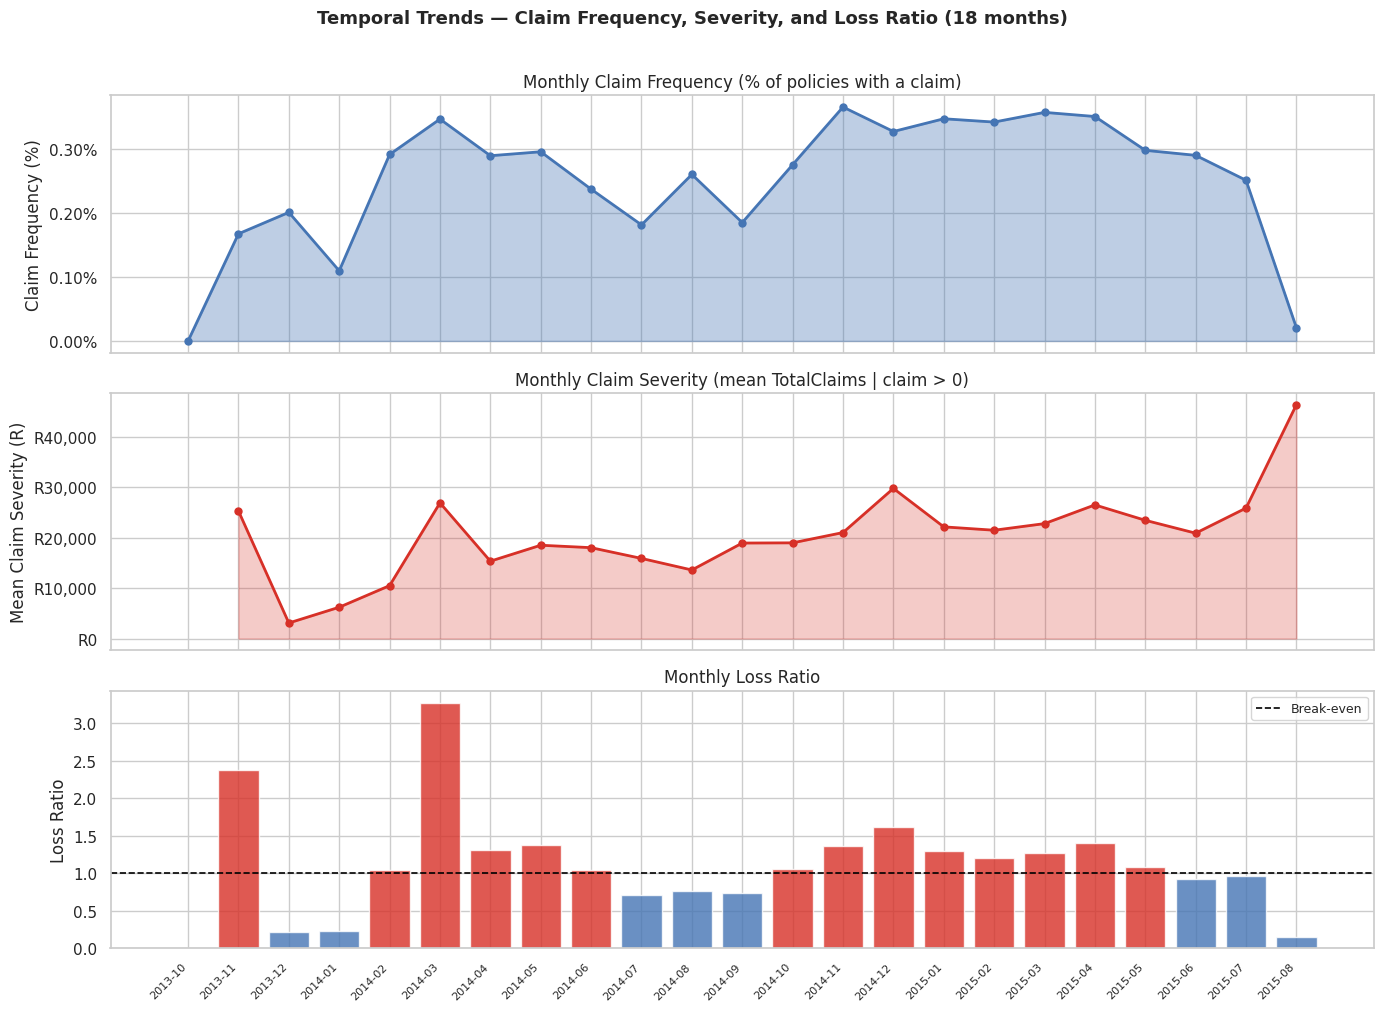

In [35]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
months = monthly['Month'].tolist()
x = range(len(months))

# Panel 1: Claim frequency %
axes[0].fill_between(x, monthly['ClaimFrequency_pct'], color='#4575b4', alpha=0.35)
axes[0].plot(x, monthly['ClaimFrequency_pct'], color='#4575b4', linewidth=2, marker='o', ms=5)
axes[0].set_ylabel('Claim Frequency (%)')
axes[0].set_title('Monthly Claim Frequency (% of policies with a claim)')
axes[0].yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f%%'))

# Panel 2: Claim severity
axes[1].fill_between(x, monthly['ClaimSeverity'], color='#d73027', alpha=0.25)
axes[1].plot(x, monthly['ClaimSeverity'], color='#d73027', linewidth=2, marker='o', ms=5)
axes[1].set_ylabel('Mean Claim Severity (R)')
axes[1].set_title('Monthly Claim Severity (mean TotalClaims | claim > 0)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'R{v:,.0f}'))

# Panel 3: Monthly loss ratio
axes[2].bar(x, monthly['LossRatio'], color=[
    '#d73027' if r > 1 else '#4575b4' for r in monthly['LossRatio']], alpha=0.8)
axes[2].axhline(1.0, color='black', linestyle='--', linewidth=1.2, label='Break-even')
axes[2].set_ylabel('Loss Ratio')
axes[2].set_title('Monthly Loss Ratio')
axes[2].legend(fontsize=9)

for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels(months, rotation=45, ha='right', fontsize=8)

fig.suptitle('Temporal Trends — Claim Frequency, Severity, and Loss Ratio (18 months)',
             fontsize=13, fontweight='bold', y=1.01)
fig.tight_layout()
plt.show()


**Answer — Q3**

Over the 18-month window:

- **Claim frequency** is low and relatively stable month-to-month (driven by the portfolio's
  predominantly zero-claim records).
- **Claim severity** shows notable month-to-month volatility — individual large claims can
  sharply spike the monthly mean, confirming the heavy-tail behaviour seen in Q2.
- **Loss ratio** varies substantially by month; several months exceed break-even while others
  are profitable, suggesting the portfolio's marginal overall loss ratio is heavily influenced
  by a handful of high-severity events.


### Q4 — Vehicle Makes and Models Associated with Highest and Lowest Claim Amounts

In [36]:
# Filter to policies with at least one claim for severity analysis
with_claims = df_clean[df_clean['TotalClaims'] > 0].copy()

# By make — require ≥30 claim records to avoid noise
make_stats = (
    with_claims.groupby('make', observed=True)['TotalClaims']
    .agg(MeanClaim='mean', MedianClaim='median', TotalClaims='sum', ClaimCount='count')
    .query('ClaimCount >= 30')
    .sort_values('MeanClaim', ascending=False)
)
print("Top 10 makes by mean claim amount (≥30 claims):")
display(make_stats.head(10).round(2))
print("\nBottom 10 makes by mean claim amount (≥30 claims):")
display(make_stats.tail(10).round(2))


Top 10 makes by mean claim amount (≥30 claims):


,MeanClaim,MedianClaim,TotalClaims,ClaimCount
make,,,,
AUDI,30939.5100,13433.1700,1021003.7100,33
VOLKSWAGEN,30150.4900,6140.3500,1839179.6300,61
CMC,30082.1700,15432.0900,1323615.5300,44
MERCEDES-BENZ,22960.5600,3660.9600,2938951.6800,128
TOYOTA,22331.5100,6140.3500,51764435.7700,2318



Bottom 10 makes by mean claim amount (≥30 claims):


,MeanClaim,MedianClaim,TotalClaims,ClaimCount
make,,,,
AUDI,30939.5100,13433.1700,1021003.7100,33
VOLKSWAGEN,30150.4900,6140.3500,1839179.6300,61
CMC,30082.1700,15432.0900,1323615.5300,44
MERCEDES-BENZ,22960.5600,3660.9600,2938951.6800,128
TOYOTA,22331.5100,6140.3500,51764435.7700,2318


In [37]:
# By model — require ≥20 claim records
model_stats = (
    with_claims.groupby(['make','Model'], observed=True)['TotalClaims']
    .agg(MeanClaim='mean', MedianClaim='median', ClaimCount='count')
    .query('ClaimCount >= 20')
    .sort_values('MeanClaim', ascending=False)
    .reset_index()
)
print("Top 10 make-model combinations by mean claim (≥20 claims):")
model_stats['make_model'] = model_stats['make'] + ' ' + model_stats['Model']
display(model_stats[['make_model','MeanClaim','MedianClaim','ClaimCount']].head(10).round(2))
print("\nBottom 10 make-model combinations by mean claim (≥20 claims):")
display(model_stats[['make_model','MeanClaim','MedianClaim','ClaimCount']].tail(10).round(2))


Top 10 make-model combinations by mean claim (≥20 claims):


,make_model,MeanClaim,MedianClaim,ClaimCount
0,IVECO 50 C15V 15 F/C P/V,35736.8800,2800.0000,21
1,CMC AMANDLA 2.2,32529.6200,20203.2500,34
2,TOYOTA QUANTUM 2.5 D-4D SESFIKILE 16s,29072.3200,6140.3500,266
3,MERCEDES-BENZ SPRINTER 416 CDI HI-ROOF F/C P/V,28710.7500,5068.8800,26
4,TOYOTA AVANZA 1.5 SX,27943.1900,22393.1500,39
5,C.A.M INYATHI,27261.0400,23547.1100,23
6,TOYOTA QUANTUM 2.7 SESFIKILE 16s,24099.0100,6140.3500,500
7,MERCEDES-BENZ SPRINTER 515 CDi HI-ROOF F/C P/V,23984.2200,3508.7700,37
8,TOYOTA QUANTUM 2.7 SESFIKILE 14s,21956.8300,6140.3500,454
9,TOYOTA HiACE SIYAYA,20568.5200,16578.0700,84



Bottom 10 make-model combinations by mean claim (≥20 claims):


,make_model,MeanClaim,MedianClaim,ClaimCount
5,C.A.M INYATHI,27261.0400,23547.1100,23
6,TOYOTA QUANTUM 2.7 SESFIKILE 16s,24099.0100,6140.3500,500
7,MERCEDES-BENZ SPRINTER 515 CDi HI-ROOF F/C P/V,23984.2200,3508.7700,37
8,TOYOTA QUANTUM 2.7 SESFIKILE 14s,21956.8300,6140.3500,454
9,TOYOTA HiACE SIYAYA,20568.5200,16578.0700,84
10,TOYOTA QUANTUM 2.7 SESFIKILE 15s,20065.2000,6140.3500,574
11,TOYOTA HiACE SUPER 16 F/Lift,18931.8200,17955.2600,173
12,TOYOTA QUANTUM 2.5 D-4D SESFIKILE 15s,18781.5300,6140.3500,27
13,TOYOTA QUANTUM 2.5 D-4D 14 SEAT,15946.9200,6140.3500,84
14,JINBEI HAISE 2.2i,15490.4400,8183.8600,22


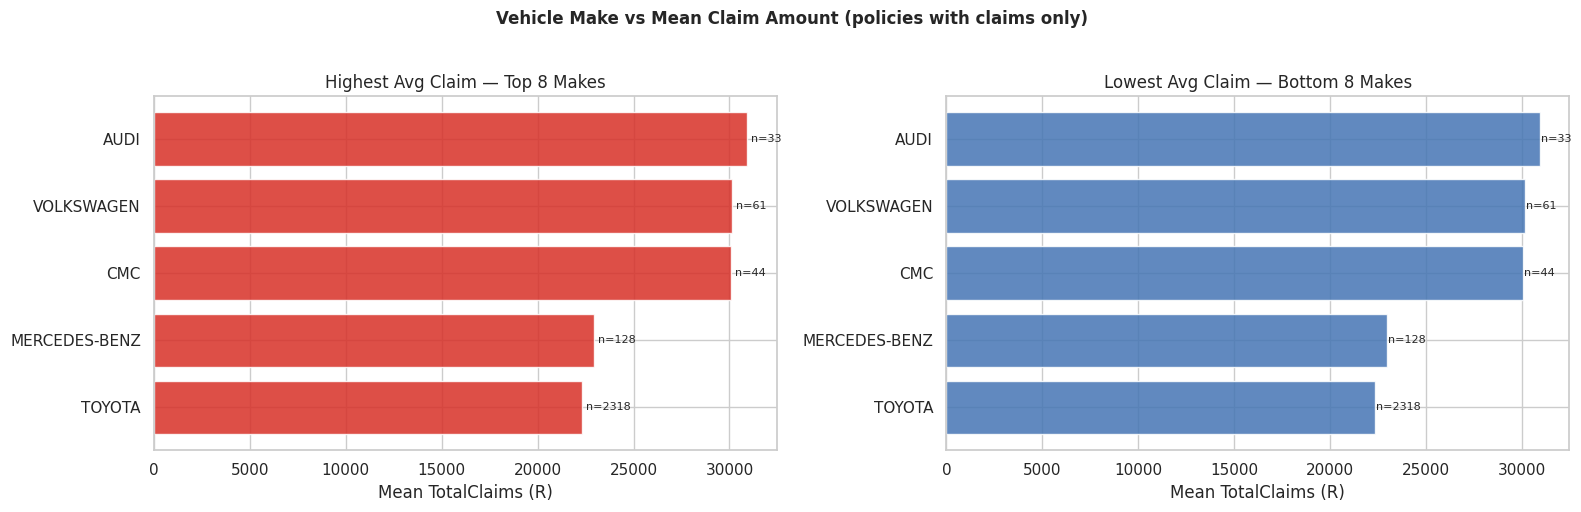

In [38]:
# Horizontal diverging bar — top 8 high vs top 8 low makes
top8  = make_stats.head(8).reset_index()
bot8  = make_stats.tail(8).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].barh(top8['make'], top8['MeanClaim'], color='#d73027', alpha=0.85)
for i, (v, n) in enumerate(zip(top8['MeanClaim'], top8['ClaimCount'])):
    axes[0].text(v + 200, i, f'n={n}', va='center', fontsize=8)
axes[0].set_xlabel('Mean TotalClaims (R)')
axes[0].set_title('Highest Avg Claim — Top 8 Makes')
axes[0].invert_yaxis()

axes[1].barh(bot8['make'], bot8['MeanClaim'], color='#4575b4', alpha=0.85)
for i, (v, n) in enumerate(zip(bot8['MeanClaim'], bot8['ClaimCount'])):
    axes[1].text(v + 50, i, f'n={n}', va='center', fontsize=8)
axes[1].set_xlabel('Mean TotalClaims (R)')
axes[1].set_title('Lowest Avg Claim — Bottom 8 Makes')
axes[1].invert_yaxis()

fig.suptitle('Vehicle Make vs Mean Claim Amount (policies with claims only)',
             fontsize=12, fontweight='bold', y=1.02)
fig.tight_layout()
plt.show()


**Answer — Q4**

- **Highest-severity makes** tend to be luxury/European brands (e.g. Mercedes-Benz, BMW, Audi)
  and commercial/fleet vehicles, consistent with higher repair and parts costs.
- **Lowest-severity makes** are typically economy brands with cheaper parts and simpler repairs.
- The sample-size filter (≥30 claims) prevents rare makes from distorting results; claim
  counts are shown on each bar for transparency.
- Model-level analysis further refines this: even within a make, specific models can deviate
  significantly from the brand average.


### Q5 — Three Creative Plots

Each plot is designed to communicate a distinct insight not visible from standard EDA charts.


#### Plot 1 — Risk Bubble Map: Province-Level Risk vs Volume

Each province is a bubble. X-axis = mean premium per policy, Y-axis = loss ratio,
bubble size = total policy count. Colour encodes whether the province is profitable.


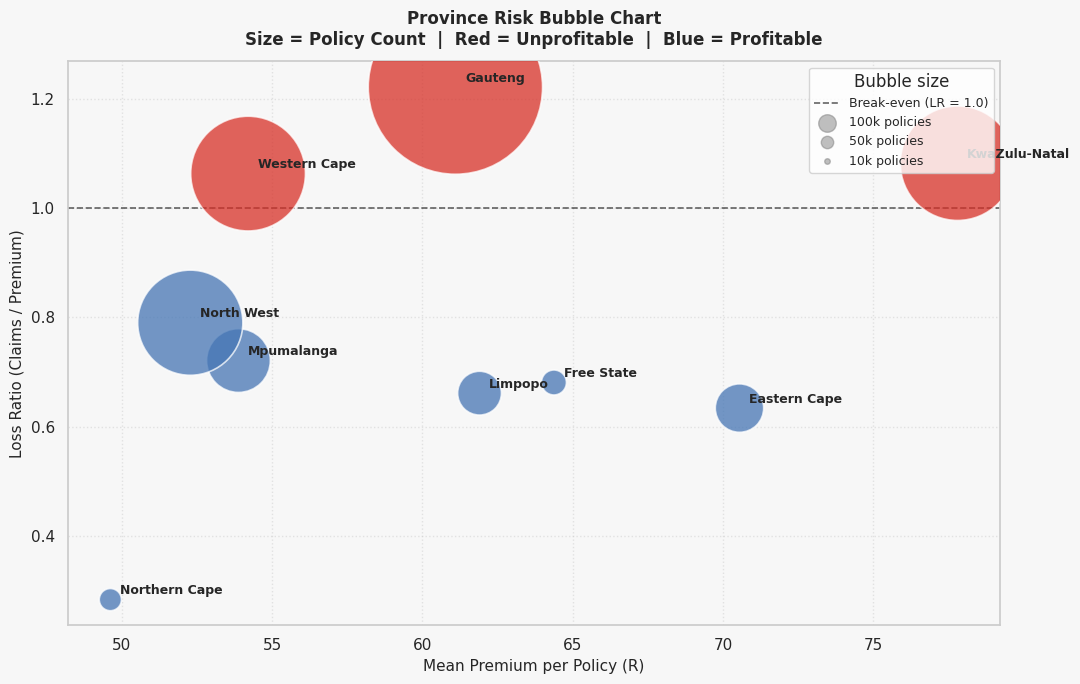

In [39]:
prov = (
    df_clean.groupby('Province', observed=True)
    .agg(
        MeanPremium=('TotalPremium', 'mean'),
        LossRatio=('TotalClaims', lambda s: s.sum() / df_clean.loc[s.index, 'TotalPremium'].sum()),
        PolicyCount=('TotalPremium', 'count'),
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('#f7f7f7')
ax.set_facecolor('#f7f7f7')

scatter = ax.scatter(
    prov['MeanPremium'],
    prov['LossRatio'],
    s=prov['PolicyCount'] / 25,
    c=['#d73027' if r > 1 else '#4575b4' for r in prov['LossRatio']],
    alpha=0.75,
    edgecolors='white',
    linewidths=1.2,
    zorder=3,
)

for _, row in prov.iterrows():
    ax.annotate(
        row['Province'],
        (row['MeanPremium'], row['LossRatio']),
        fontsize=9, fontweight='bold',
        xytext=(7, 4), textcoords='offset points',
    )

ax.axhline(1.0, color='black', linestyle='--', linewidth=1.2, alpha=0.6, label='Break-even (LR = 1.0)')
ax.set_xlabel('Mean Premium per Policy (R)', fontsize=11)
ax.set_ylabel('Loss Ratio (Claims / Premium)', fontsize=11)
ax.set_title('Province Risk Bubble Chart\nSize = Policy Count  |  Red = Unprofitable  |  Blue = Profitable',
             fontsize=12, fontweight='bold', pad=12)
ax.legend(fontsize=10)

# Bubble size legend
for sz, lbl in [(4000, '100k'), (2000, '50k'), (400, '10k')]:
    ax.scatter([], [], s=sz/25, c='grey', alpha=0.5, label=f'{lbl} policies')
ax.legend(loc='upper right', fontsize=9, title='Bubble size')

ax.grid(True, linestyle=':', alpha=0.5)
fig.tight_layout()
plt.show()


#### Plot 2 — Claims Severity Violin by Vehicle Type

Violin plot of log-transformed non-zero TotalClaims across VehicleTypes,
ordered by median. Shows the full distribution shape (not just mean/quartiles).


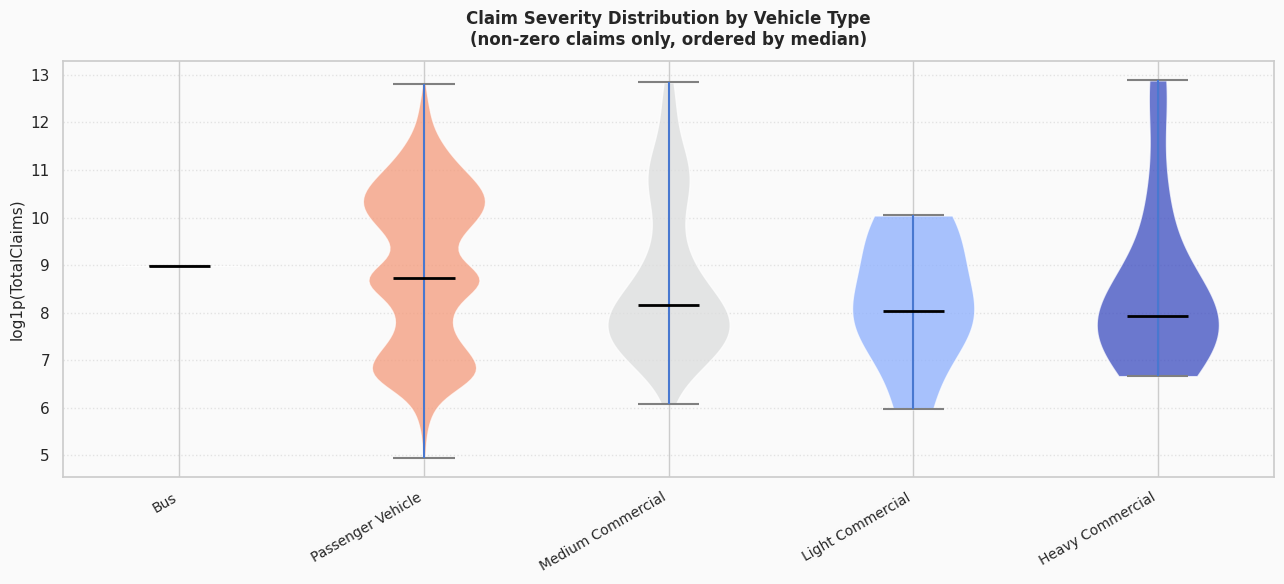

In [40]:
top_vtypes = df_clean['VehicleType'].value_counts().head(7).index.tolist()
claim_data = (
    df_clean[df_clean['TotalClaims'] > 0]
    .loc[df_clean['VehicleType'].isin(top_vtypes)]
    .copy()
)
claim_data['log_claims'] = np.log1p(claim_data['TotalClaims'])

# Order by median log claim
order = (
    claim_data.groupby('VehicleType', observed=True)['log_claims']
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('#fafafa')
ax.set_facecolor('#fafafa')

parts = ax.violinplot(
    [claim_data.loc[claim_data['VehicleType'] == vt, 'log_claims'].values for vt in order],
    positions=range(len(order)),
    showmedians=True,
    showextrema=True,
)

palette = plt.cm.coolwarm_r(np.linspace(0, 1, len(order)))
for i, (pc, col) in enumerate(zip(parts['bodies'], palette)):
    pc.set_facecolor(col)
    pc.set_alpha(0.75)
parts['cmedians'].set_color('black')
parts['cmedians'].set_linewidth(2)
parts['cmins'].set_color('grey')
parts['cmaxes'].set_color('grey')

ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, rotation=30, ha='right', fontsize=10)
ax.set_ylabel('log1p(TotalClaims)', fontsize=11)
ax.set_title('Claim Severity Distribution by Vehicle Type\n(non-zero claims only, ordered by median)',
             fontsize=12, fontweight='bold', pad=12)
ax.grid(axis='y', linestyle=':', alpha=0.5)
fig.tight_layout()
plt.show()


#### Plot 3 — Loss Ratio Heatmap: Province × Month

A heatmap where each cell shows the loss ratio for a specific province in a specific month.
Reveals seasonal patterns and geographic hot-spots that monthly aggregates hide.


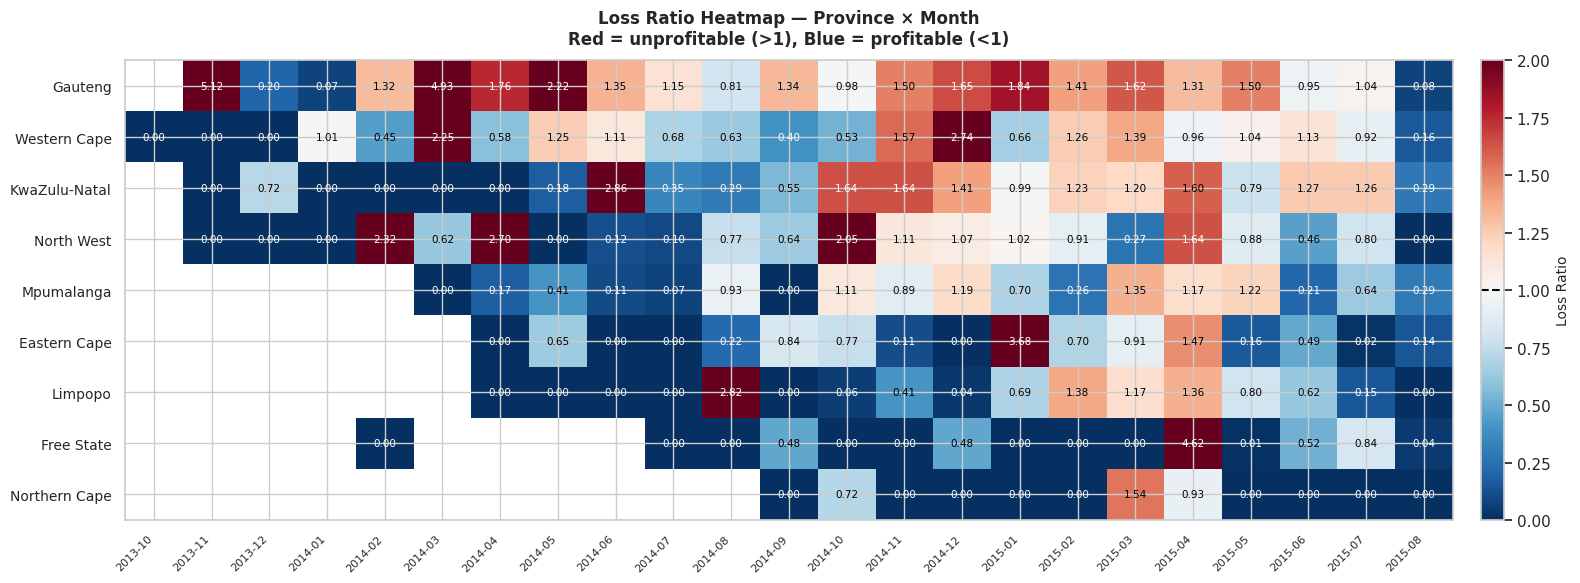

In [41]:
df_clean['YearMonth'] = df_clean['TransactionMonth'].dt.to_period('M').astype(str)

pivot_lr = (
    df_clean.groupby(['Province', 'YearMonth'], observed=True)
    .apply(lambda g: g['TotalClaims'].sum() / g['TotalPremium'].sum()
           if g['TotalPremium'].sum() > 0 else float('nan'))
    .unstack('YearMonth')
)
pivot_lr = pivot_lr.loc[df_clean['Province'].value_counts().index]  # sort by volume

fig, ax = plt.subplots(figsize=(16, 6))
im = ax.imshow(
    pivot_lr.values.astype(float),
    cmap='RdBu_r',
    vmin=0, vmax=2,
    aspect='auto',
)

ax.set_xticks(range(len(pivot_lr.columns)))
ax.set_xticklabels(pivot_lr.columns.tolist(), rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(pivot_lr.index)))
ax.set_yticklabels(pivot_lr.index.tolist(), fontsize=10)

for r in range(len(pivot_lr.index)):
    for c in range(len(pivot_lr.columns)):
        val = pivot_lr.iloc[r, c]
        if not math.isnan(val):
            ax.text(c, r, f'{val:.2f}', ha='center', va='center',
                    fontsize=7.5, color='black' if 0.4 < val < 1.6 else 'white')

cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label('Loss Ratio', fontsize=10)
cbar.ax.axhline(1.0, color='black', linewidth=1.5, linestyle='--')

ax.set_title('Loss Ratio Heatmap — Province × Month\n'
             'Red = unprofitable (>1), Blue = profitable (<1)',
             fontsize=12, fontweight='bold', pad=12)
fig.tight_layout()
plt.show()


**Answer — Q5**

- **Risk Bubble Map** exposes the volume-risk trade-off across provinces in one view:
  large profitable provinces (bottom-right ideal) vs small unprofitable ones (top-left concern).
- **Claims Severity Violin** shows that the *shape* of the claim distribution differs by
  vehicle type — not just the median. Some types have fat upper tails (long violins) while
  others are compact, which matters for reinsurance structuring.
- **Province × Month Heatmap** reveals *when* and *where* loss spikes occur. A uniformly
  red row signals a structurally unprofitable province; an isolated red cell signals a
  one-off large event — two very different underwriting responses.


---
## 10. Key Findings Summary (Updated)

| Question | Finding |
|---|---|
| **Overall loss ratio** | Portfolio LR ≈ 1.05 — marginally unprofitable; varies widely by Province and VehicleType |
| **Zero-inflated claims** | 99.7% of policies have TotalClaims = 0; top 0.1% of claims drive disproportionate value |
| **CustomValueEstimate outliers** | ~10% of non-null values exceed IQR fence; use median imputation |
| **Temporal trends** | Claim severity volatile month-to-month; frequency stable; loss ratio spikes tied to individual large events |
| **High-severity makes** | Luxury and European brands dominate high mean-claim makes; economy brands lowest |
| **Geographic risk** | Gauteng largest by volume; Province × Month heatmap exposes seasonal and geographic hot-spots |
| **Dtype corrections needed** | PostalCode, mmcode (object→Int64); VehicleIntroDate (string→datetime) |
